In [41]:
getRversion()

[1] ‘4.3.1’

In [22]:
library(dplyr)
library(tidyr)
library(ggplot2)
# library(multcompView)
# library(stringr)

# library(viridis)
# library(car)
library(lme4)
library(lmerTest)
library(AICcmodavg)
# library(data.table)

# library(ggExtra)
options(repr.plot.width=16, repr.plot.height=10) #make all the plots large

also installing the dependencies ‘TMB’, ‘unmarked’, ‘VGAM’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


Attaching package: ‘AICcmodavg’


The following object is masked from ‘package:lme4’:

    checkConv




# Import and Visualize data

In [43]:
data_full <- read.csv(file = "../Data/Parsed_Temperature_Screen.csv")[,-1]
head(data_full)

,Cell_Line,Temperature,Time,Rep,Area,Batch,Incubator,Day
,<chr>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<int>
1,CC1690,16,0,0,0,1,B,0
2,CC1690,16,0,1,0,1,B,0
3,CC1690,16,0,2,0,1,B,0
4,CC1690,16,0,3,0,1,B,0
5,CC1690,16,0,4,0,1,B,0
6,CC1690,16,0,5,0,1,B,0


`geom_smooth()` using formula = 'y ~ x'


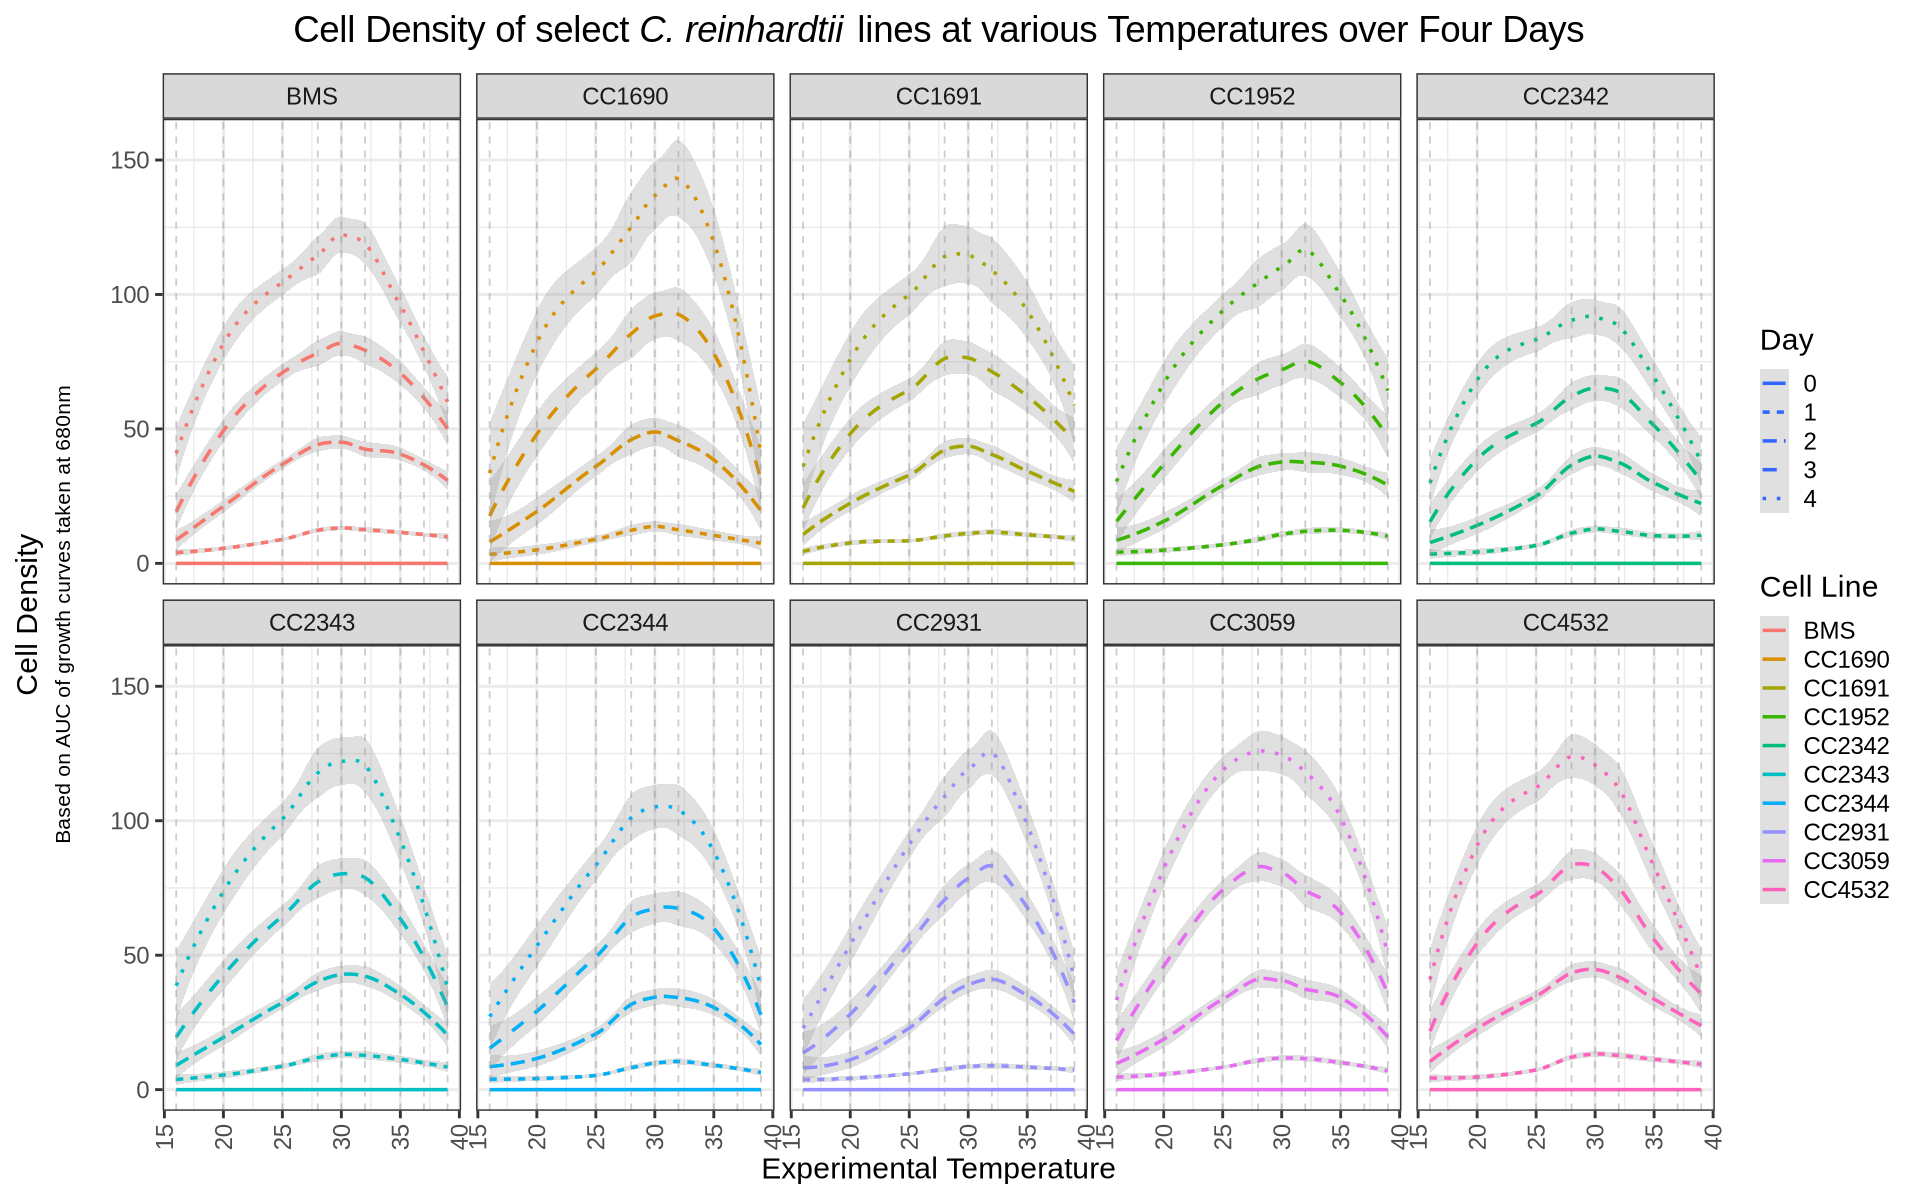

In [44]:
options(repr.plot.width=16, repr.plot.height=10) #make all the plots large

# Plot area under the curve by day. Don't take the average so that you can get error bars
data_full %>%
    na.omit() %>%
    mutate(Day = factor(Day)) %>%
    ggplot(aes(x = Temperature, y = Area, group = Day, col = Cell_Line, linetype = Day))+
        stat_smooth(method="loess", se=TRUE, alpha=0.3) +
        facet_wrap(~Cell_Line, nrow = 2) +
        theme_bw(base_size = 18) +
        theme(plot.title = element_text(size=22, hjust = 0.5), 
              axis.text.x = element_text(angle = 90, vjust = 0.5))+
        labs(x = "Experimental Temperature", 
             y= expression(atop("Cell Density", atop("Based on AUC of growth curves taken at 680nm"))), 
             title = expression(paste("Cell Density of select ", italic("C. reinhardtii"), " lines at various Temperatures over Four Days")),
             color="Cell Line")+
        geom_vline(xintercept = c(unique(data_full$Temperature)), linetype = "dashed", col = "grey60", alpha = 0.5)

# GLMMS
### Check Batch Effect

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



	Shapiro-Wilk normality test

data:  .
W = 0.95037, p-value = 0.003894


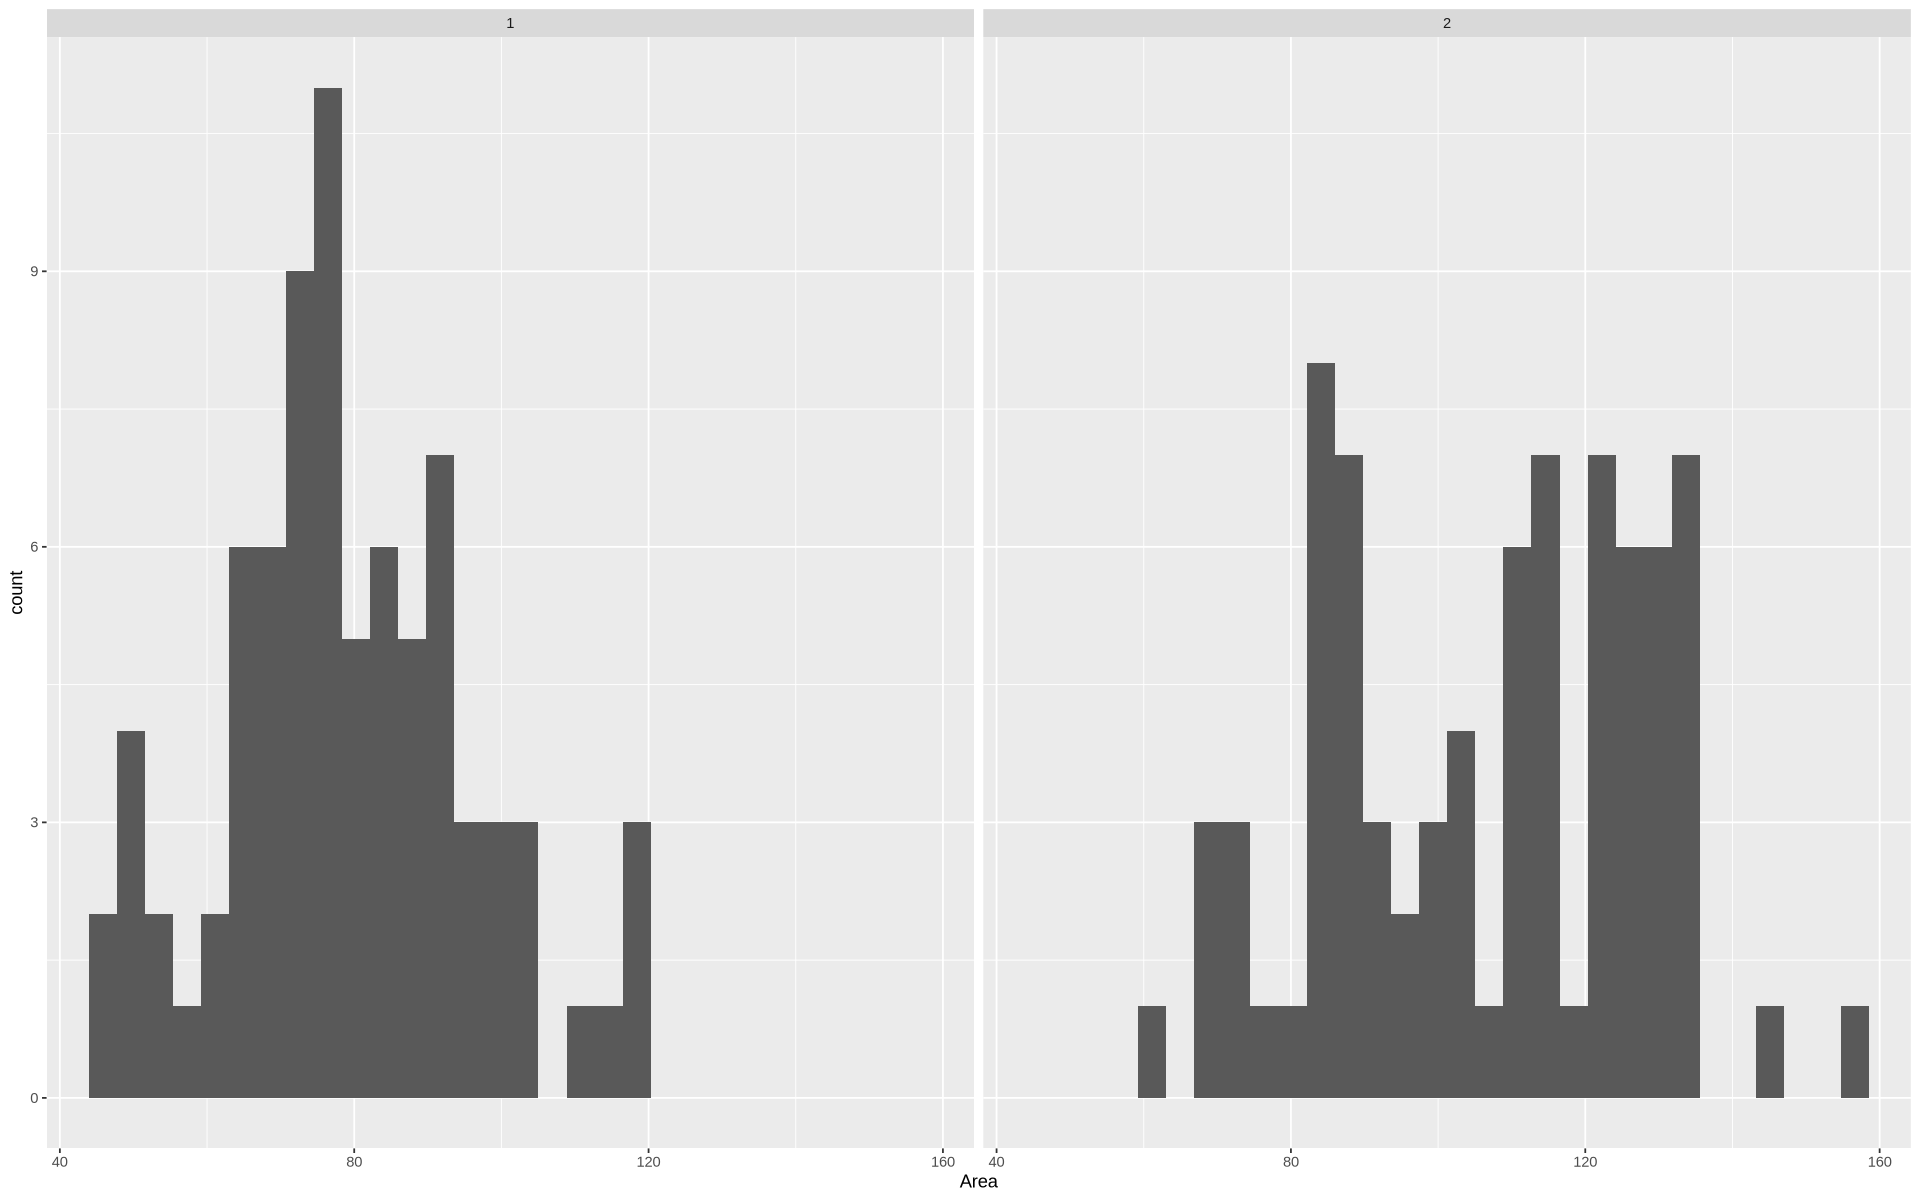

In [45]:
# The top incubator was the only incubator used twice for the same temperature
batch_effect <- data_full %>% 
    filter(Temperature == 25, Day == 4, Incubator == "T") %>%
    mutate(log10_Area = log10(Area))

ggplot(batch_effect, aes(Area))+
    geom_histogram() +
    facet_wrap(~Batch)

# Is the data normal? No. Batch 2 isn't normal enough
batch_effect %>% 
    filter(Batch == 2) %>% 
    pull(log10_Area) %>%
    shapiro.test()
    # qqPlot()

In [46]:
# Fit a model with Batch as a fixed effect and Cell_Line as a random effect
model <- lmer(Area ~ Batch + (1|Cell_Line), data = batch_effect)
summary(model)

# There is a significant effect of batch in our data

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Area ~ Batch + (1 | Cell_Line)
   Data: batch_effect

REML criterion at convergence: 1341.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9725 -0.6039 -0.0421  0.6192  3.2757 

Random effects:
 Groups    Name        Variance Std.Dev.
 Cell_Line (Intercept) 139.5    11.81   
 Residual              248.9    15.78   
Number of obs: 159, groups:  Cell_Line, 10

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)   52.076      5.436  31.082   9.581  8.6e-11 ***
Batch         27.123      2.503 148.007  10.837  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
      (Intr)
Batch -0.689

## Full Model
- Only interested in area at day 4

In [47]:
head(data_full)
model_data <- data_full %>% filter(Day == 4) %>% mutate(Temperature = factor(Temperature))

,Cell_Line,Temperature,Time,Rep,Area,Batch,Incubator,Day
,<chr>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<int>
1,CC1690,16,0,0,0,1,B,0
2,CC1690,16,0,1,0,1,B,0
3,CC1690,16,0,2,0,1,B,0
4,CC1690,16,0,3,0,1,B,0
5,CC1690,16,0,4,0,1,B,0
6,CC1690,16,0,5,0,1,B,0


In [48]:
interaction_model_full <- lmer(Area ~ Temperature * Cell_Line + (1|Batch), data = model_data, REML=FALSE)
additive_model_full <- lmer(Area ~ Temperature + Cell_Line + (1|Batch), data = model_data, REML=FALSE)


model.set <- list(interaction_model_full, additive_model_full)
model.names <- c("interaction_model_full", "additive_model_full")

aictab(model.set, modnames = model.names)

# Interaction model is better

,Modnames,K,AICc,Delta_AICc,ModelLik,AICcWt,LL,Cum.Wt
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,interaction_model_full,92,8223.270,0.00000,1.00000e+00,1.00000e+00,-4009.663,1
2,additive_model_full,20,8303.047,79.77717,4.74905e-18,4.74905e-18,-4131.072,1


In [49]:
model_full <- lmer(Area ~ Temperature * Cell_Line + (1|Batch), data = model_data)
# summary(model_full)
anova(model_full)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Temperature,374884.36,46860.545,8,851.8335,161.058715,1.093144e-164
Cell_Line,51898.53,5766.503,9,858.0008,19.819352,2.031570e-30
Temperature:Cell_Line,72971.29,1013.490,72,858.0008,3.483344,3.258216e-18


`geom_smooth()` using formula = 'y ~ x'


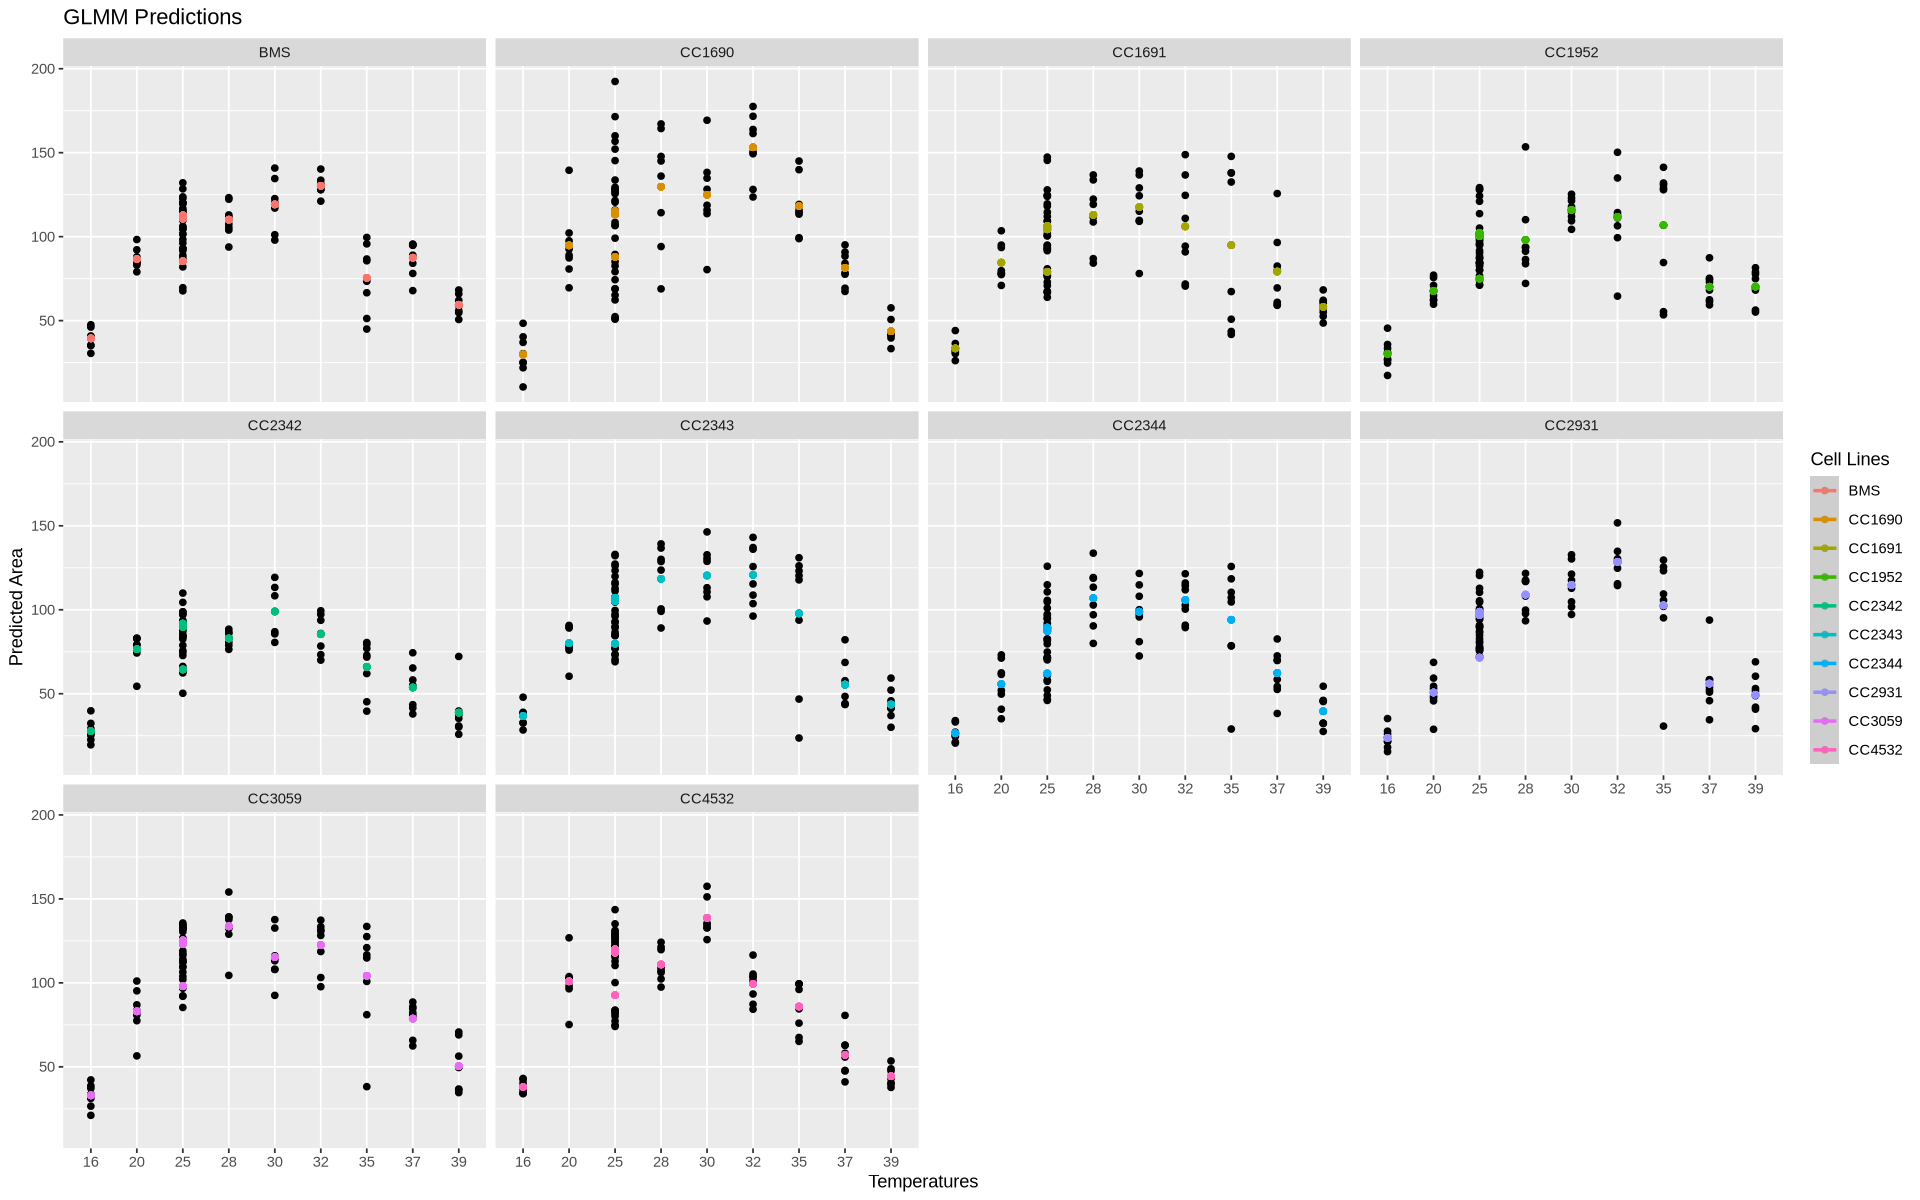

In [51]:
# Plot model and see if it fits the data:
predictions <- predict(model_full, type = "response", newdata = model_data)

ggplot(model_data, aes(x = Temperature, y = predictions, color = as.factor(Cell_Line))) +
    geom_point(data = model_data, aes(x = Temperature, y = Area), col = "black")+
    geom_point() +
    facet_wrap(~Cell_Line)+
    geom_smooth(method = "glm") +
    labs(title = "GLMM Predictions",
        x = "Temperatures",
        y = "Predicted Area",
        color = "Cell Lines")

# Fitting TPC Model
- Here the goal is to fit models on bootstrapped data to generate a confidence interval on what the Topt is. From here we can then see what the range of Topts are and whether these overlap between groups
- When fitting mutliple models, the quadratic one had the lowest AIC, however did not fit the data visually and tended to miss the curve completely. So we're going to choose the rezende model because it looks like a proper TPC and is the most recent

In [52]:
# install.packages('nls.multstart')
# install.packages("ggrepel")
library(rTPC)
library(nls.multstart)
library(broom)
library(tidyverse)
library(ggrepel)
library(MuMIn)

ERROR: Error in library(rTPC): there is no package called ‘rTPC’


In [21]:
# Create model with the original data:
original_fit <- function(d, cell_line){
    #Fit the model
    d_fit <- nls_multstart(rate~rezende_2019(temp, q10, a,b,c),
                           data = d,
                           iter = c(4,4,4,4),
                           start_lower = get_start_vals(d$temp, d$rate, model_name = 'rezende_2019') - 10,
                           start_upper = get_start_vals(d$temp, d$rate, model_name = 'rezende_2019') + 10,
                           lower = get_lower_lims(d$temp, d$rate, model_name = 'rezende_2019'),
                           upper = get_upper_lims(d$temp, d$rate, model_name = 'rezende_2019'),
                           supp_errors = 'Y')

    #Get the Optimum Temperature from the model
    topt <- get_topt(d_fit)
    topt

    # Predict data to plot
    new_data <- data.frame(temp = seq(min(d$temp), max(d$temp), 0.5))
    preds <- augment(d_fit, newdata = new_data)
    
    # Plot data and model fit
    original_fit <- ggplot() +
        geom_point(data = d, aes(temp, rate)) +
        geom_line(aes(temp, .fitted), preds, col = 'blue') +
        theme_bw(base_size = 12) +
        labs(x = 'Temperature (ºC)',
             y = 'Area', title = cell_line) +
        geom_vline(xintercept = topt, col = "red")

    # Return the plot, and the optimum temperature
    return(list(original_fit, topt))
}

In [22]:
get_strapped <- function(dt, iterations = 1000, plot){

    # Store bootstrapped topts and predictions
    bootstrapped_topt <- c()
    bootstrapped_preds <- c()

    # Loop 
    for (i in 1:iterations){
        
        # resample the data with replacement. Will need to do 25°C separately because it has more points
        boot_25 <- dt %>% filter(temp == 25)
        boot_no_25 <- dt %>% filter(temp != 25)
        boot_25 <- boot_25[, rate[sample.int(.N, 32, replace = TRUE)], by = temp]
        boot <- rbind(boot_25, boot_no_25[, rate[sample.int(.N, 8, replace = TRUE)], by = temp]) %>% rename(rate = "V1")
    
        # Fit the model with the resampled data:
        fit_boot <- nls_multstart(rate~rezende_2019(temp, q10, a,b,c),
                                data = boot,
                                iter = c(4,4,4,4),
                                start_lower = get_start_vals(boot$temp, boot$rate, model_name = 'rezende_2019') - 10,
                                start_upper = get_start_vals(boot$temp, boot$rate, model_name = 'rezende_2019') + 10,
                                lower = get_lower_lims(boot$temp, boot$rate, model_name = 'rezende_2019'),
                                upper = get_upper_lims(boot$temp, boot$rate, model_name = 'rezende_2019'),
                                supp_errors = 'Y')
        
        # get the optimum temperature and store
        bootstrapped_topt[i] <- get_topt(fit_boot)
        
        # predict new data
        new_data <- data.frame(temp = seq(min(boot$temp), max(boot$temp), 0.5))
        bootstrapped_preds <- cbind(bootstrapped_preds, augment(fit_boot, newdata = new_data)$.fitted)
    }

    # Calculate curve CI
    lower_ci <- apply(bootstrapped_preds, 1, quantile, probs = 0.025)
    upper_ci <- apply(bootstrapped_preds, 1, quantile, probs = 0.975)

    # Add to plot
    plot <- plot + geom_ribbon(aes(x = seq(min(boot$temp), max(boot$temp), 0.5), ymin = lower_ci, ymax = upper_ci), fill = "lightblue", alpha = 0.4)

    # Calculate topt CI
    topt_CI <- quantile(bootstrapped_topt,probs=c(.025,.975))

    #Return the plot and the CI of the optimal temperatures
    return(list(plot, topt_CI))
}

In [23]:
cell_lines <- unique(model_data$Cell_Line)

In [24]:
# Get the Topt for every line from the original data
original_cell_line_fits <- c()
topts <- c()
for (line in cell_lines){
    # Filter the cell line
    print(line)
    flush.console()
    d_line <- model_data %>% 
        filter(Cell_Line == line) %>%
        mutate(temp = as.numeric(as.character(Temperature)), rate = Area) %>% 
        select(temp, rate)

    #Get plot with original model fit
    original_cell_line_fits[[line]] <- original_fit(d_line, line)
    topts[line] <- original_cell_line_fits[[line]][2]
}

# Format it
topts <- data.frame(topt = t(data.frame(topts)))
topts$Cell_Line = rownames(topts)
topts %>% arrange(topt)

[1] "CC1690"
[1] "CC1691"
[1] "CC1952"
[1] "CC2342"
[1] "CC2343"
[1] "CC2344"
[1] "CC2931"
[1] "CC3059"
[1] "CC4532"
[1] "BMS"


,topt,Cell_Line
,<dbl>,<chr>
CC2342,31.179,CC2342
CC4532,31.416,CC4532
CC2343,31.527,CC2343
CC3059,31.826,CC3059
CC2344,31.839,CC2344
CC1690,31.901,CC1690
CC2931,31.981,CC2931
BMS,32.019,BMS
CC1691,32.043,CC1691


In [25]:
#Try for all the cell lines:
cell_lines <- unique(model_data$Cell_Line)

#Remove the ones already done:
# cell_lines <- cell_lines[-c(1,10)] #remove 1690 and BMS since they're already done
cell_lines

CI_Cell_Lines <- c()

[1] "CC1690" "CC1691" "CC1952" "CC2342" "CC2343" "CC2344" "CC2931" "CC3059"
 [9] "CC4532" "BMS"

In [36]:
stopCluster(my_cluster)

ERROR: Error in summary.connection(connection): invalid connection


In [26]:
# Read all the files from the bootstrap and store them 
CI_Cell_Lines <- c()

# Get file names
file_names <- list.files(path = "boostrapped_models/", full.names = TRUE)

for (file in file_names){
    line <- gsub("boostrapped_models//Boostrapped_(.*).rds", "\\1", file) #Get line name from file path
    CI_Cell_Lines[[line]] <- readRDS(file)
}

## Visualize TPC Plots

In [27]:
CI_lims_cell_lines <- c()
line_plots <- c()
for (line in cell_lines){
    line_plots[[line]] <- CI_Cell_Lines[[line]][[1]]
    CI_lims_cell_lines[[line]] <- CI_Cell_Lines[[line]][[2]]
}

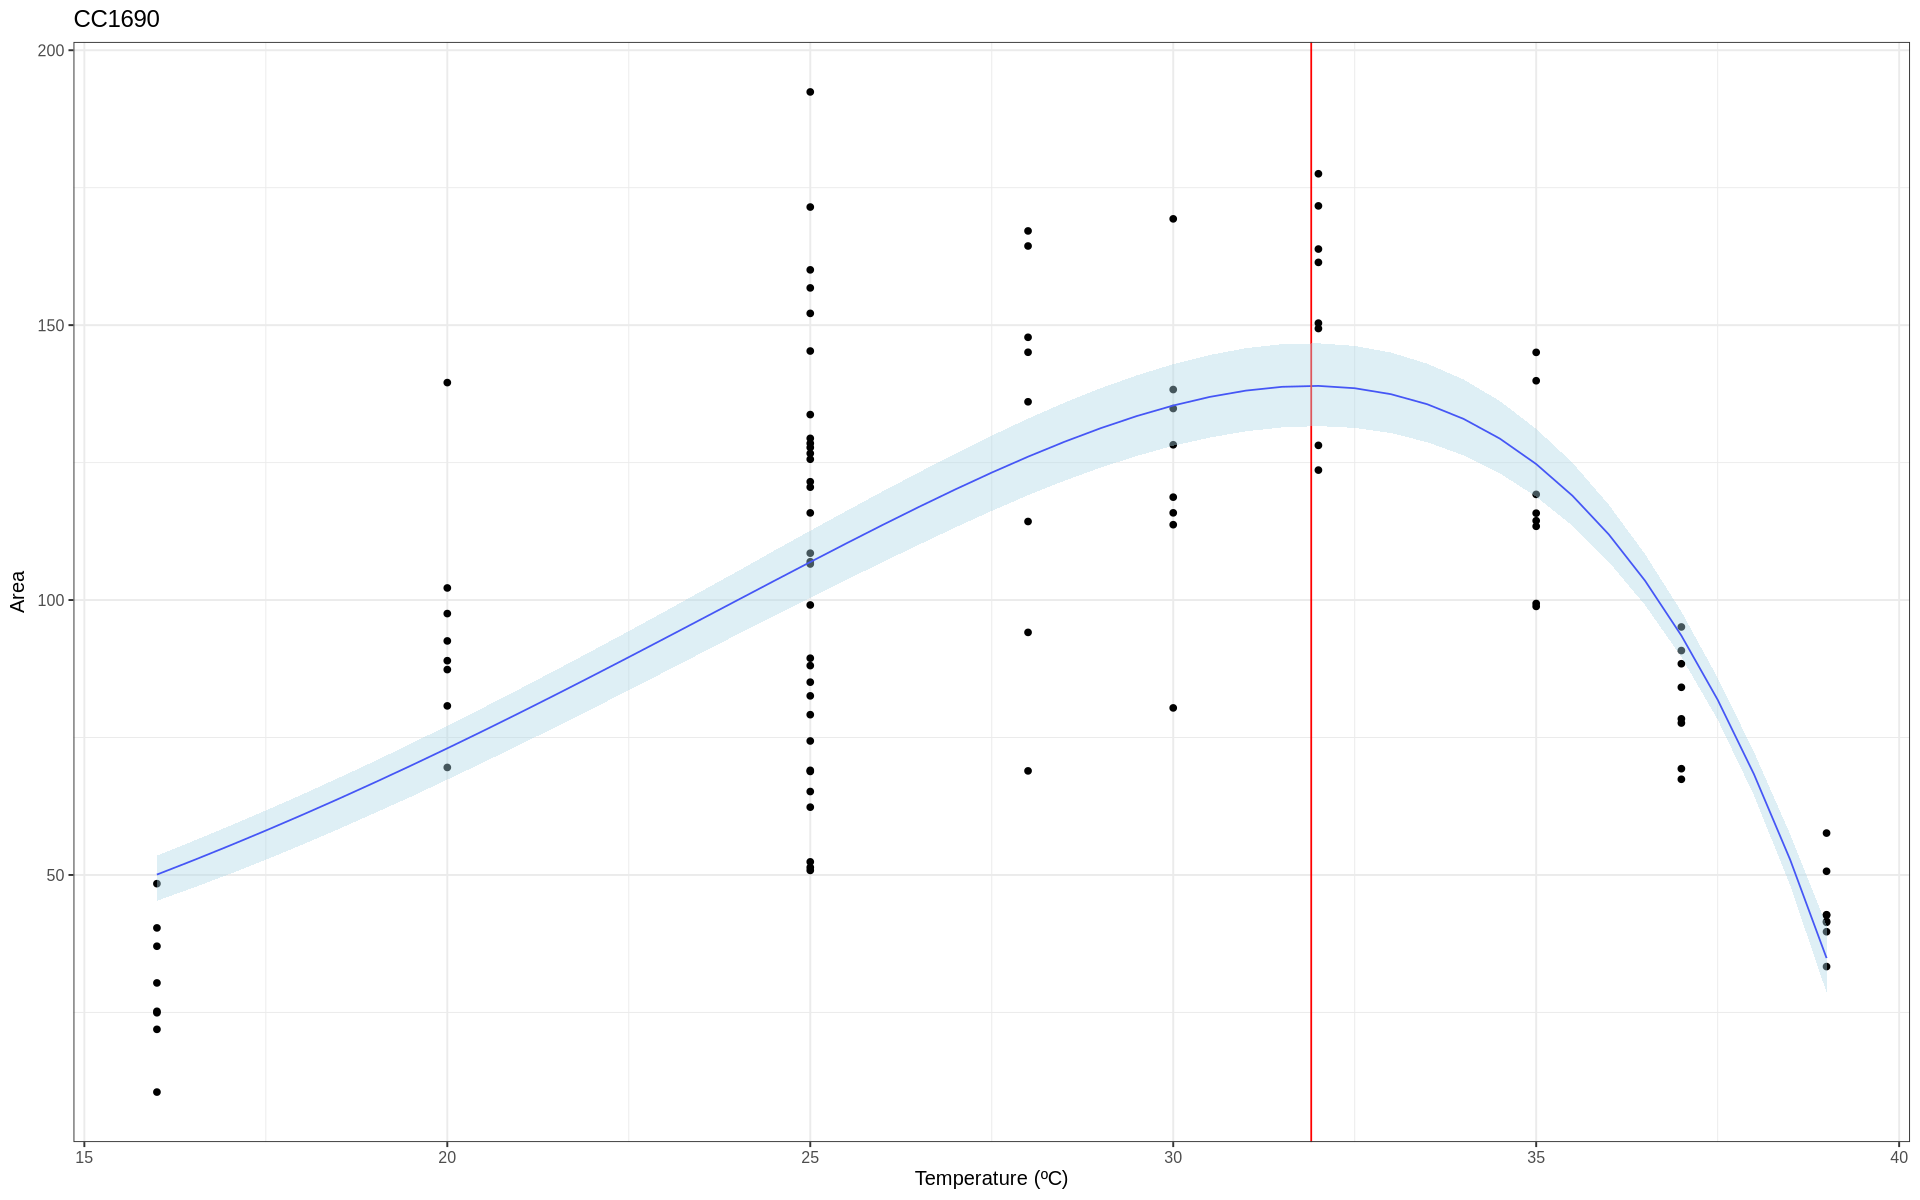

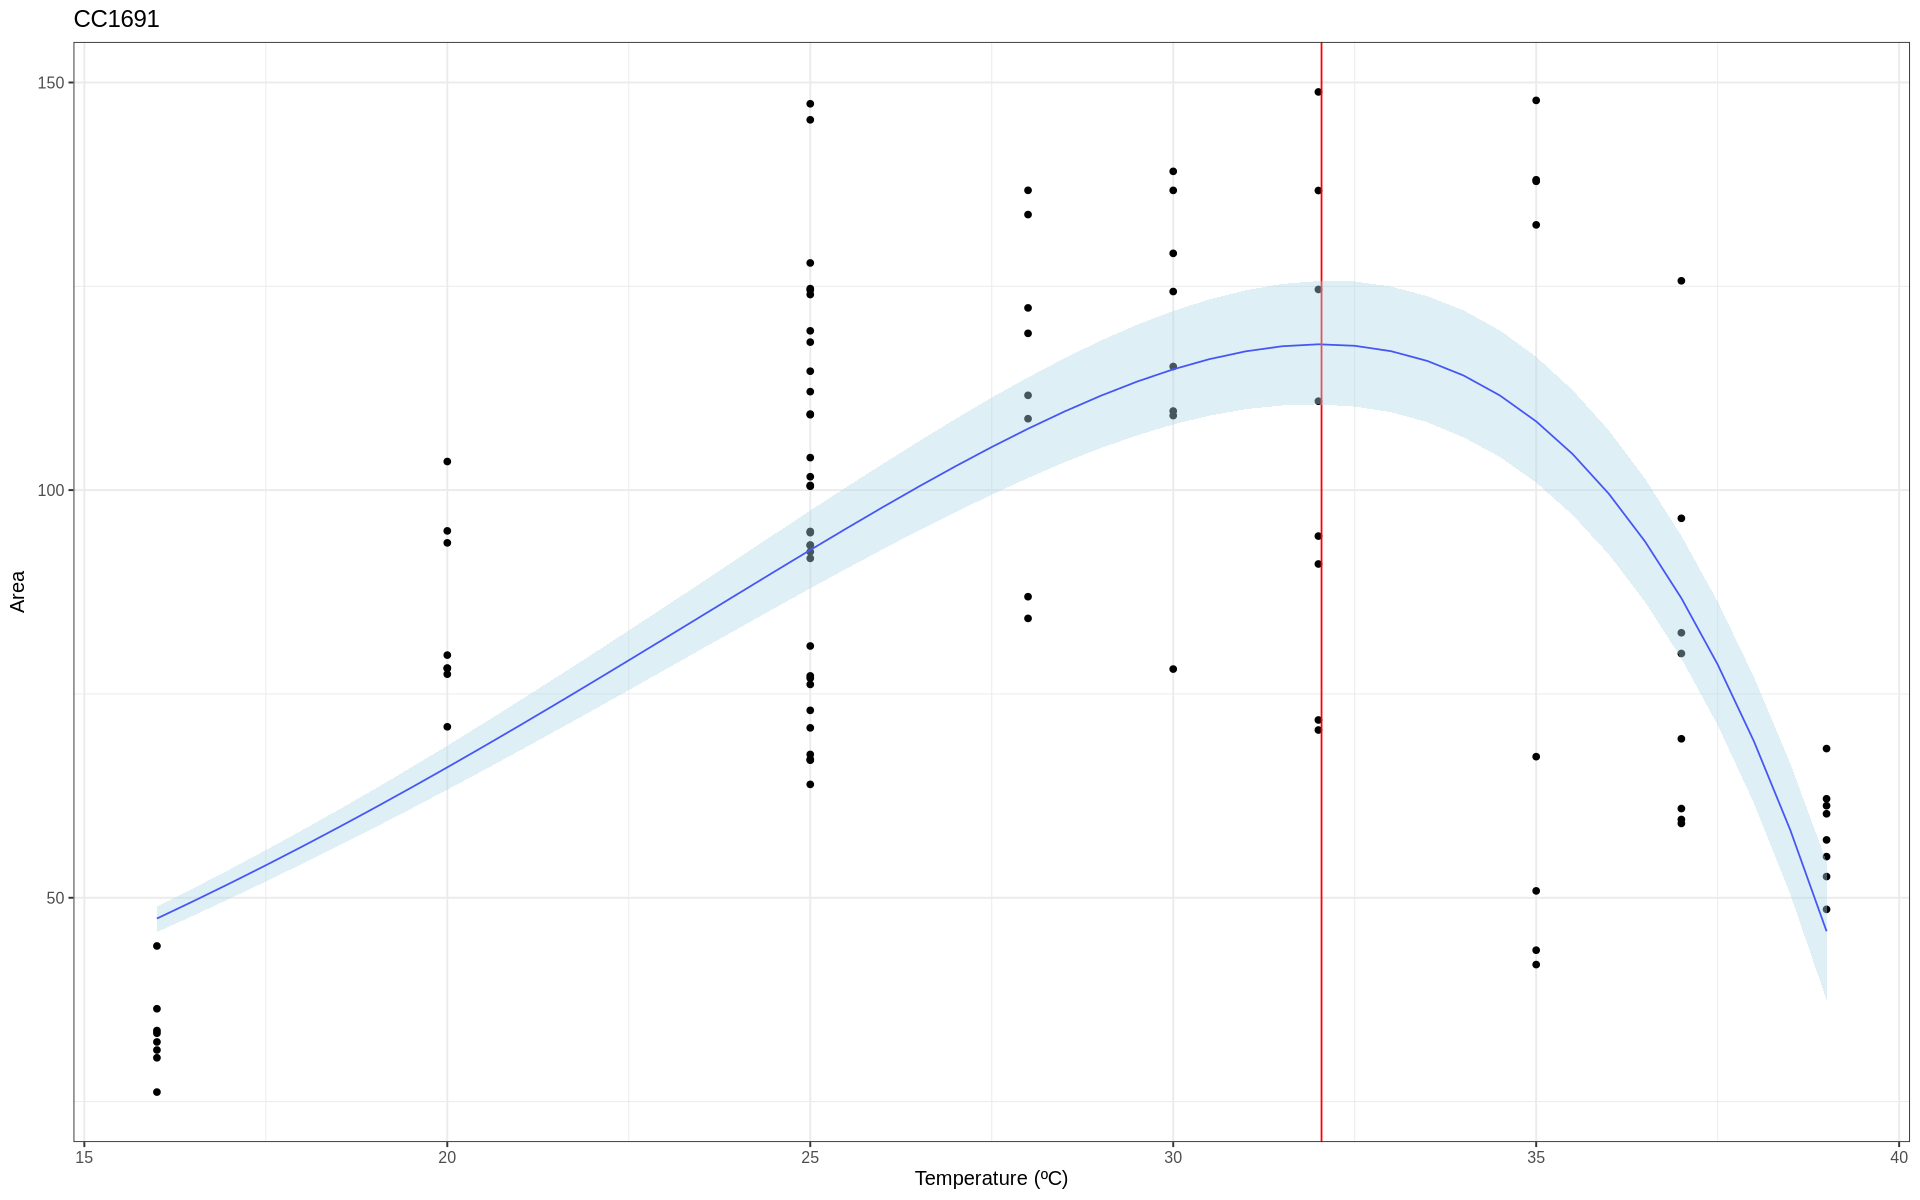

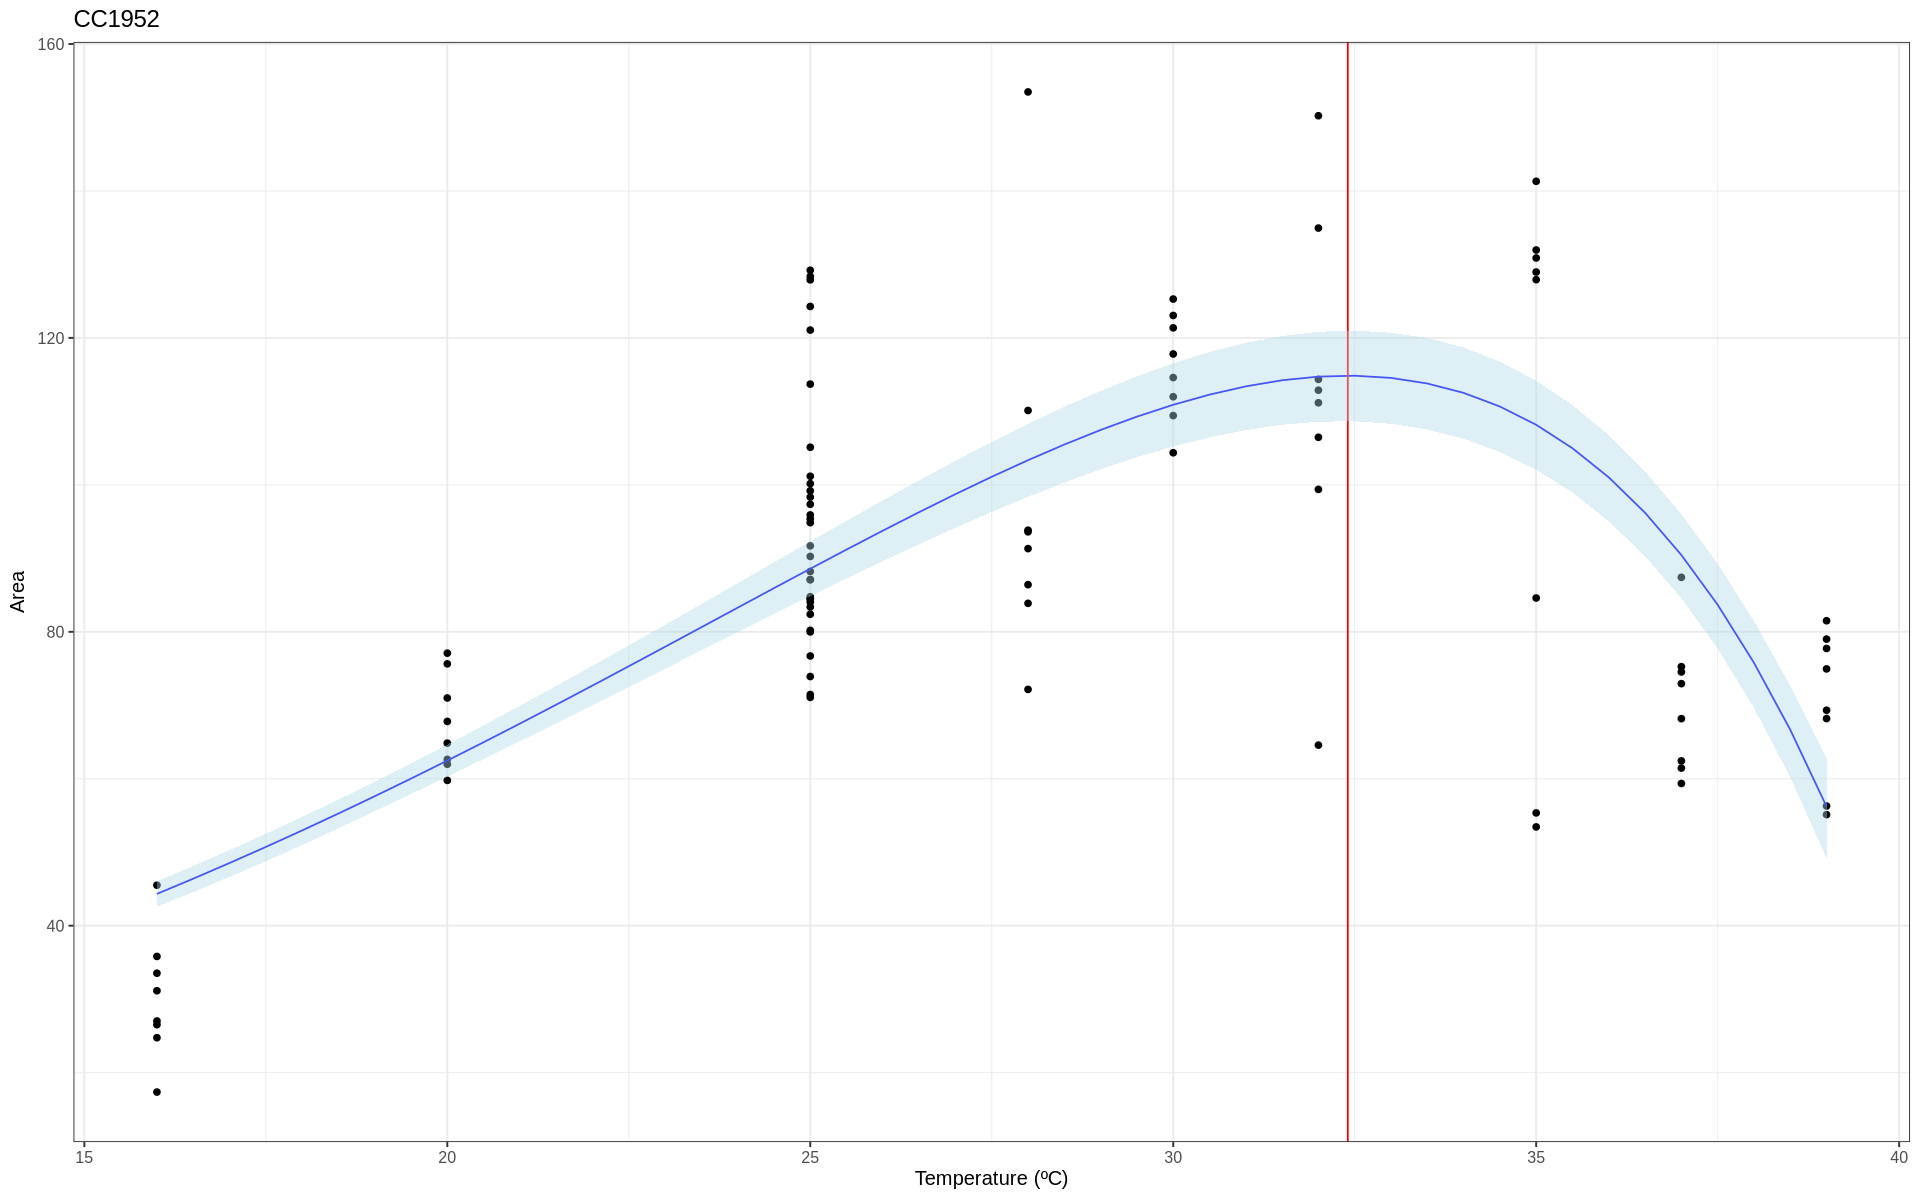

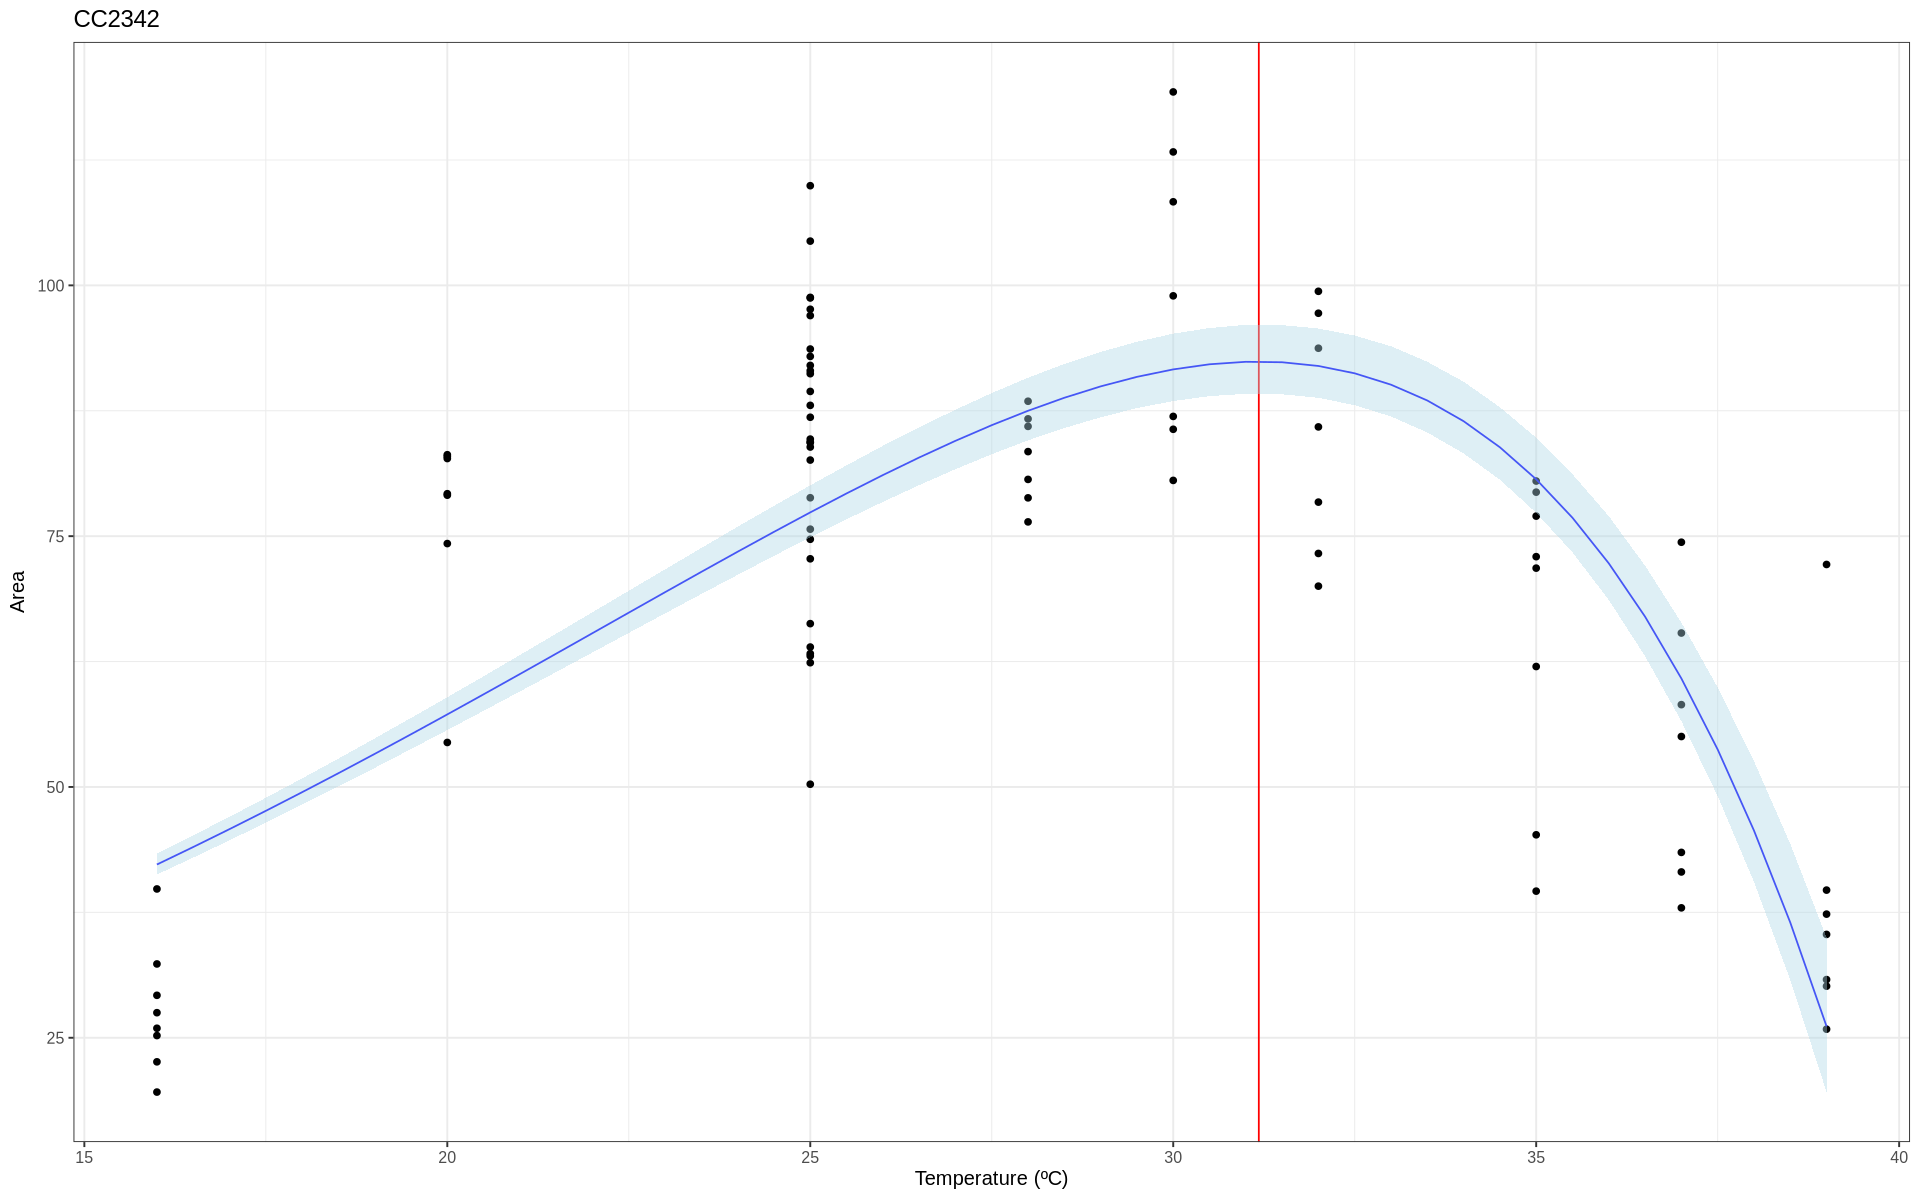

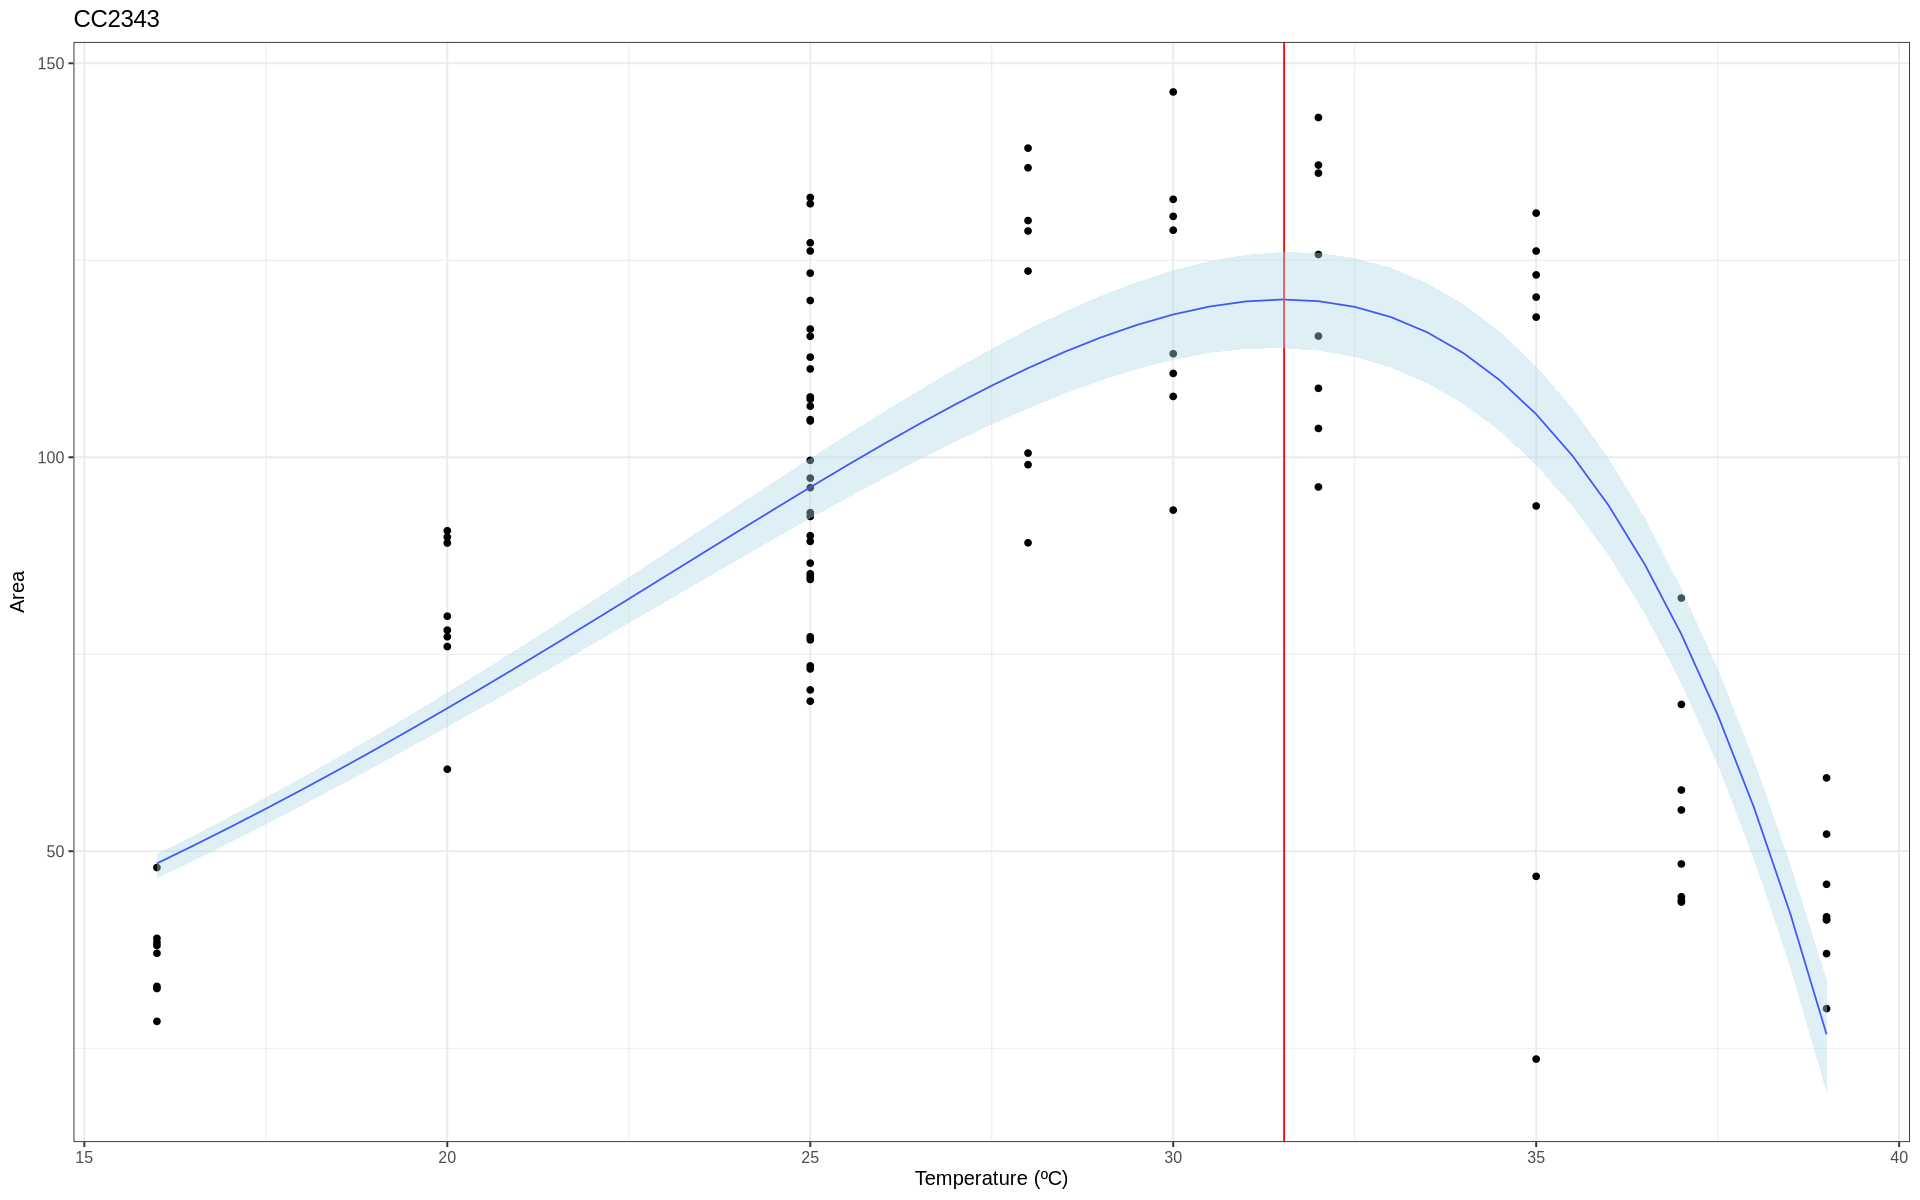

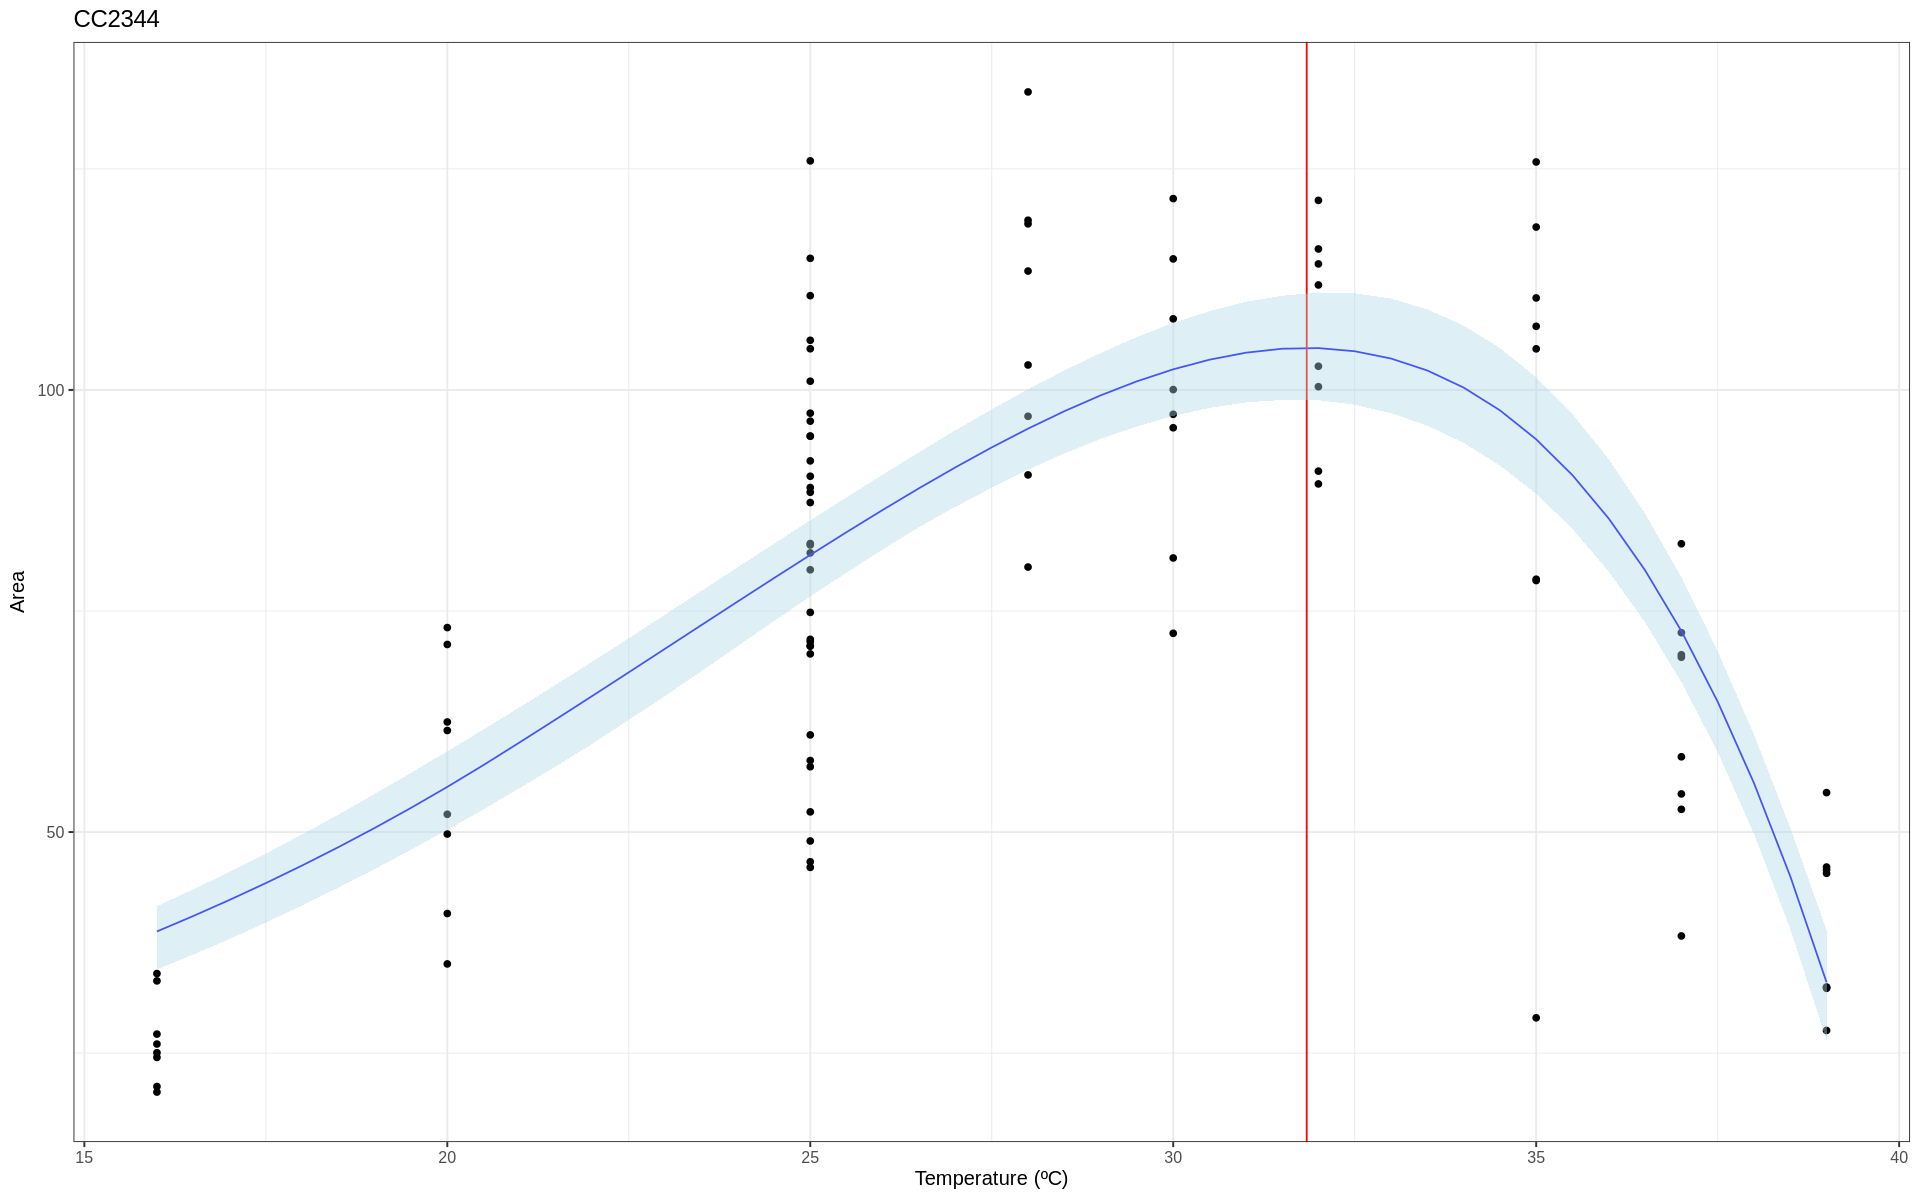

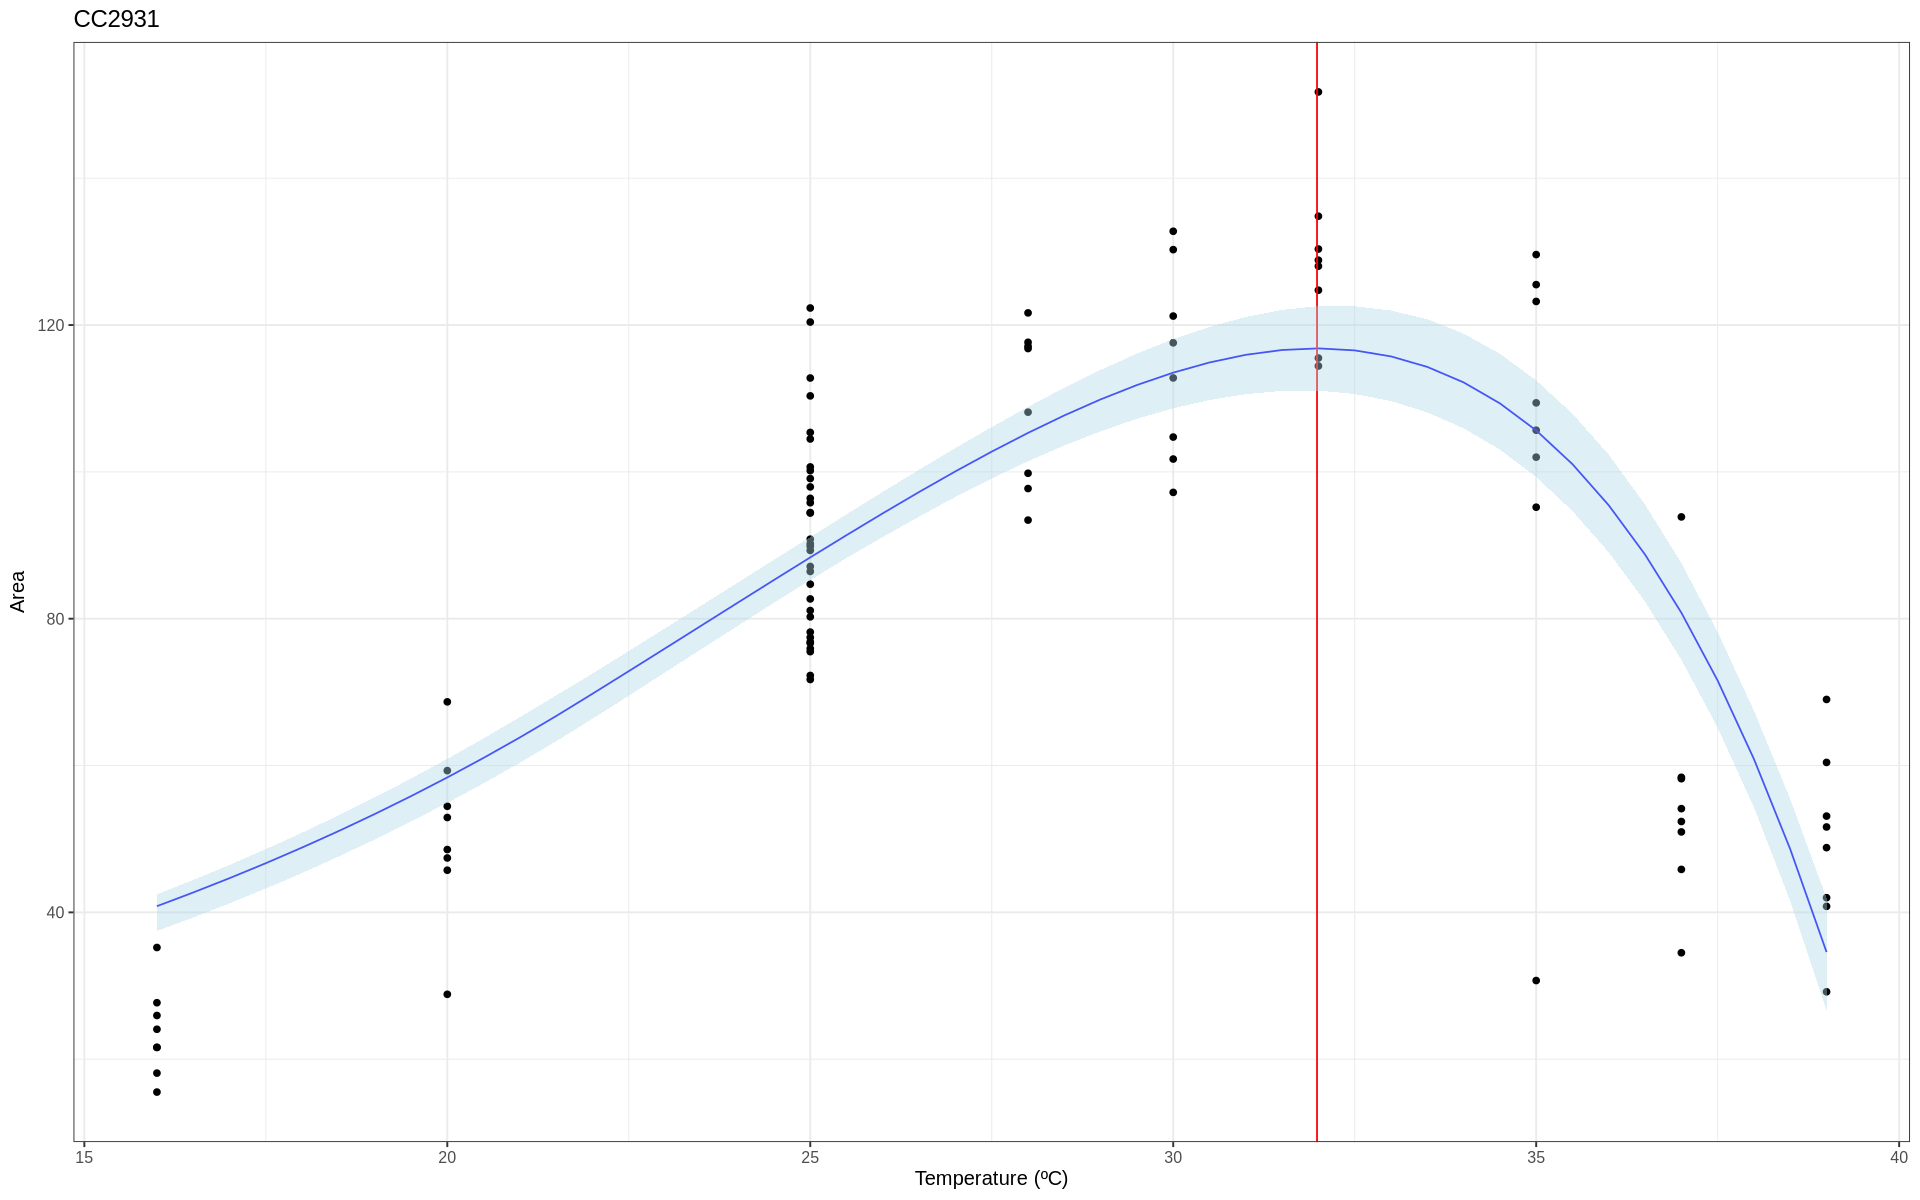

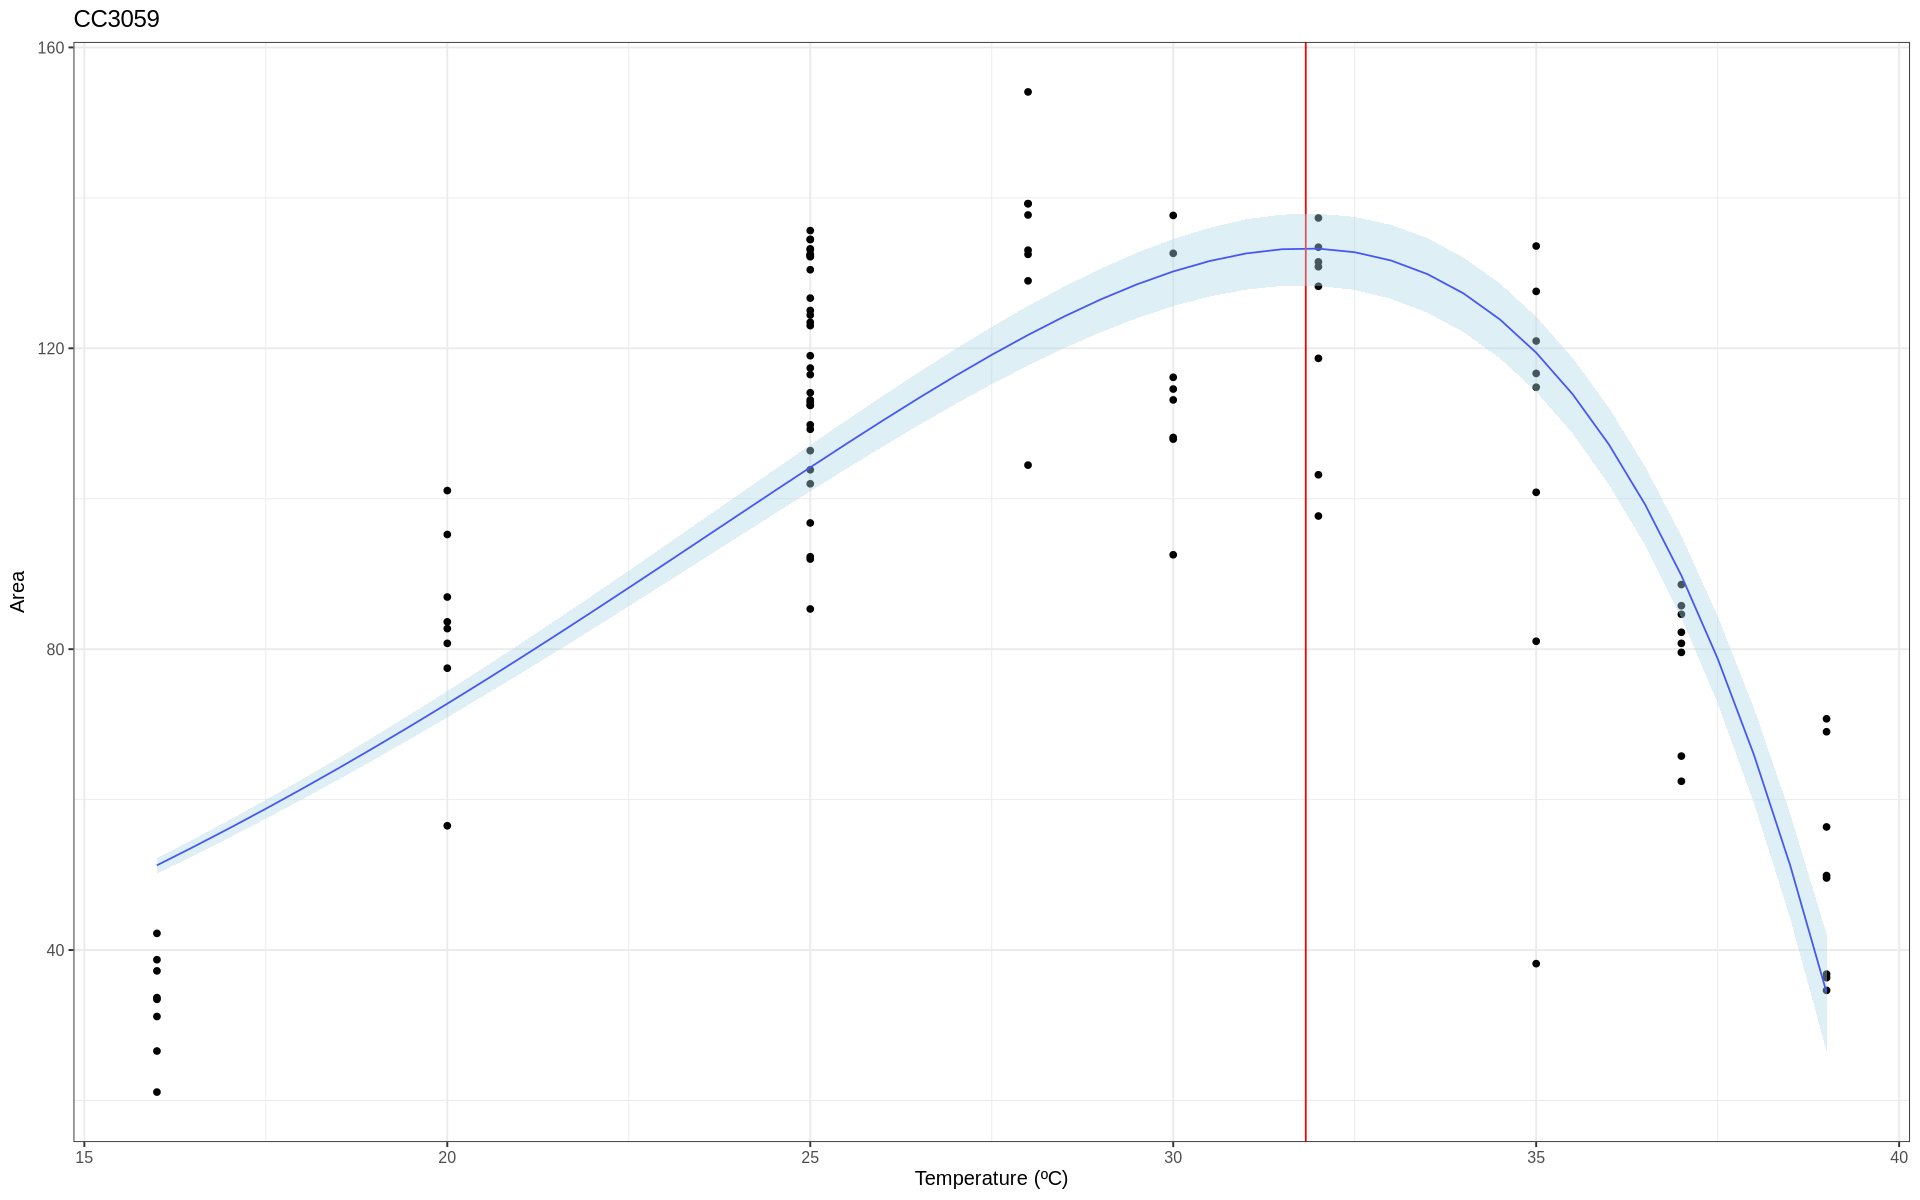

$CC1690

$CC1691

$CC1952

$CC2342

$CC2343

$CC2344

$CC2931

$CC3059

$CC4532

$BMS


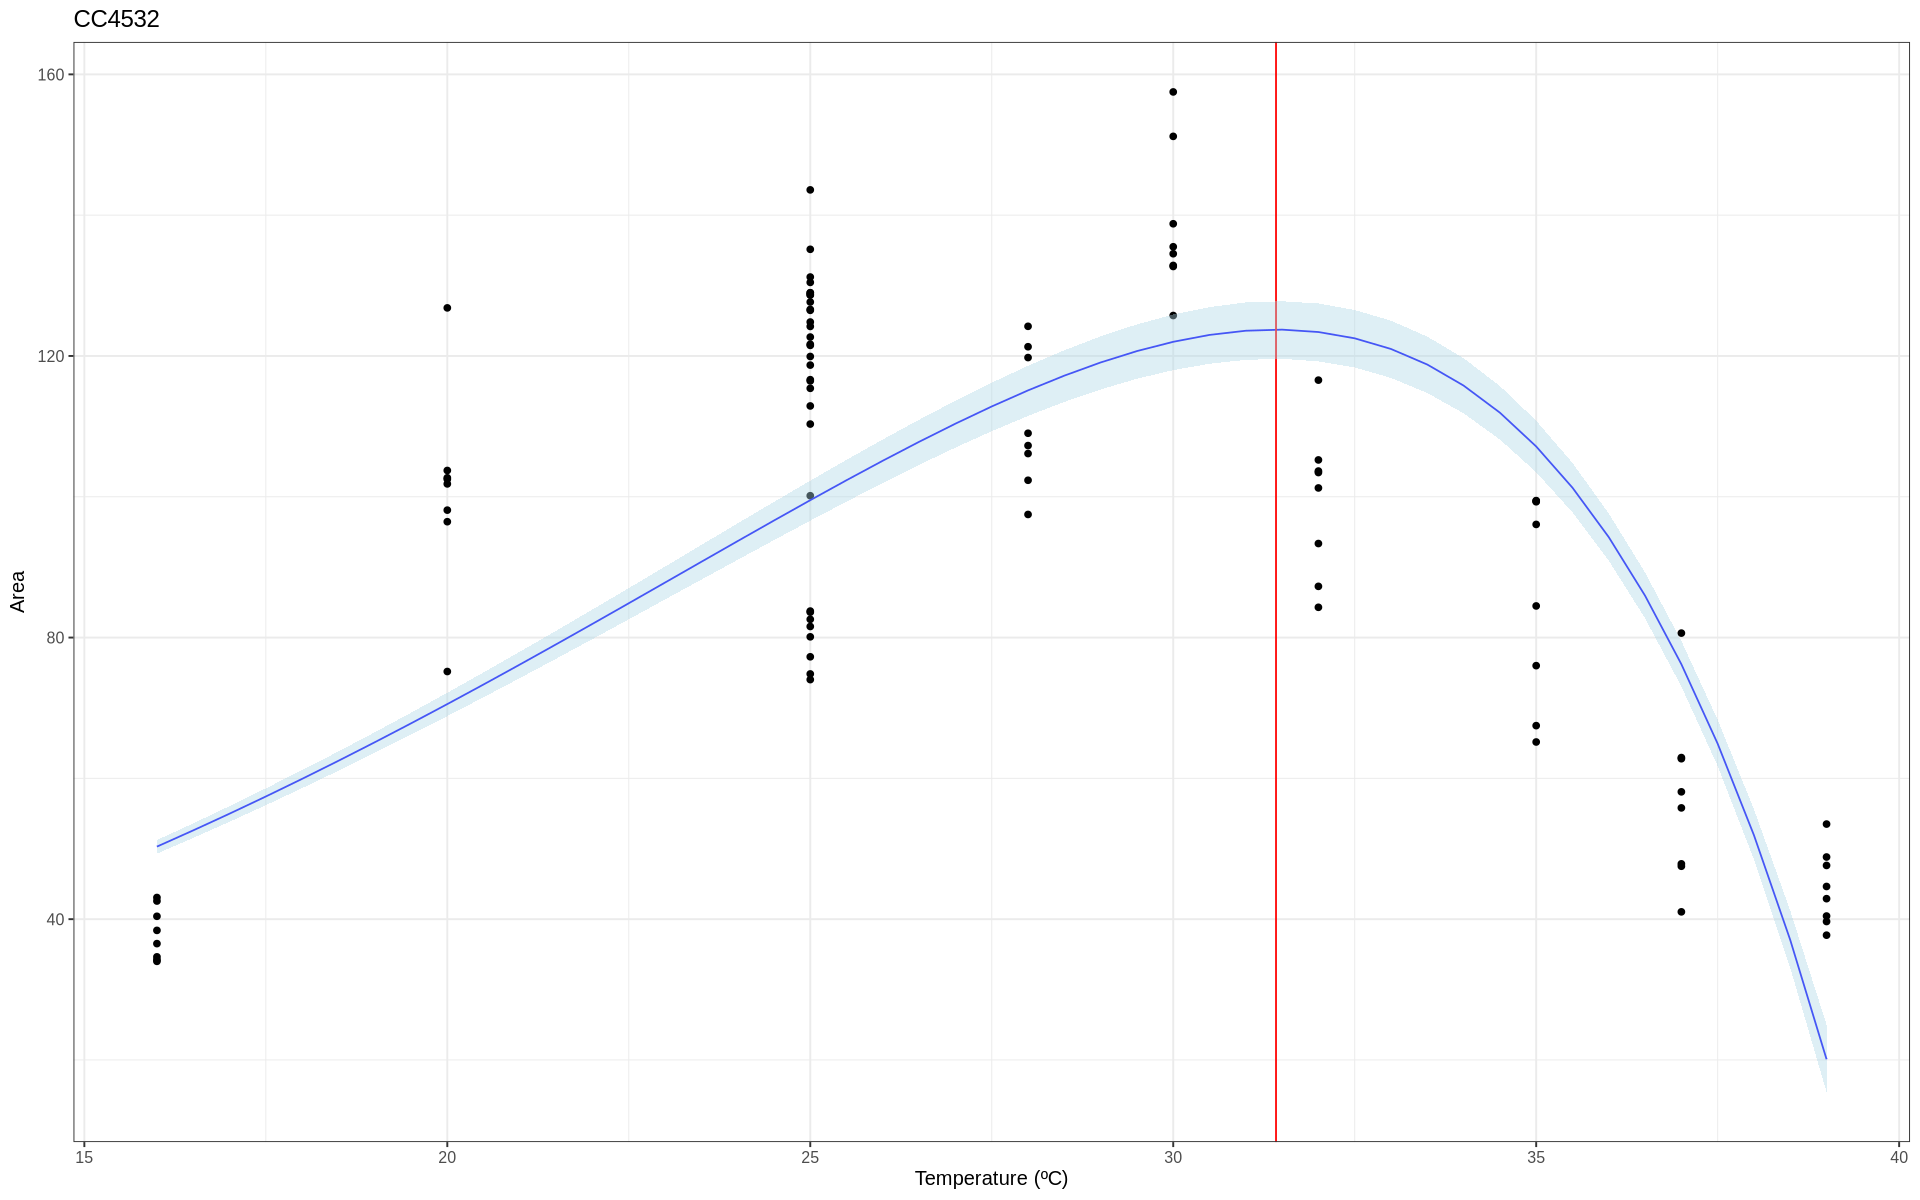

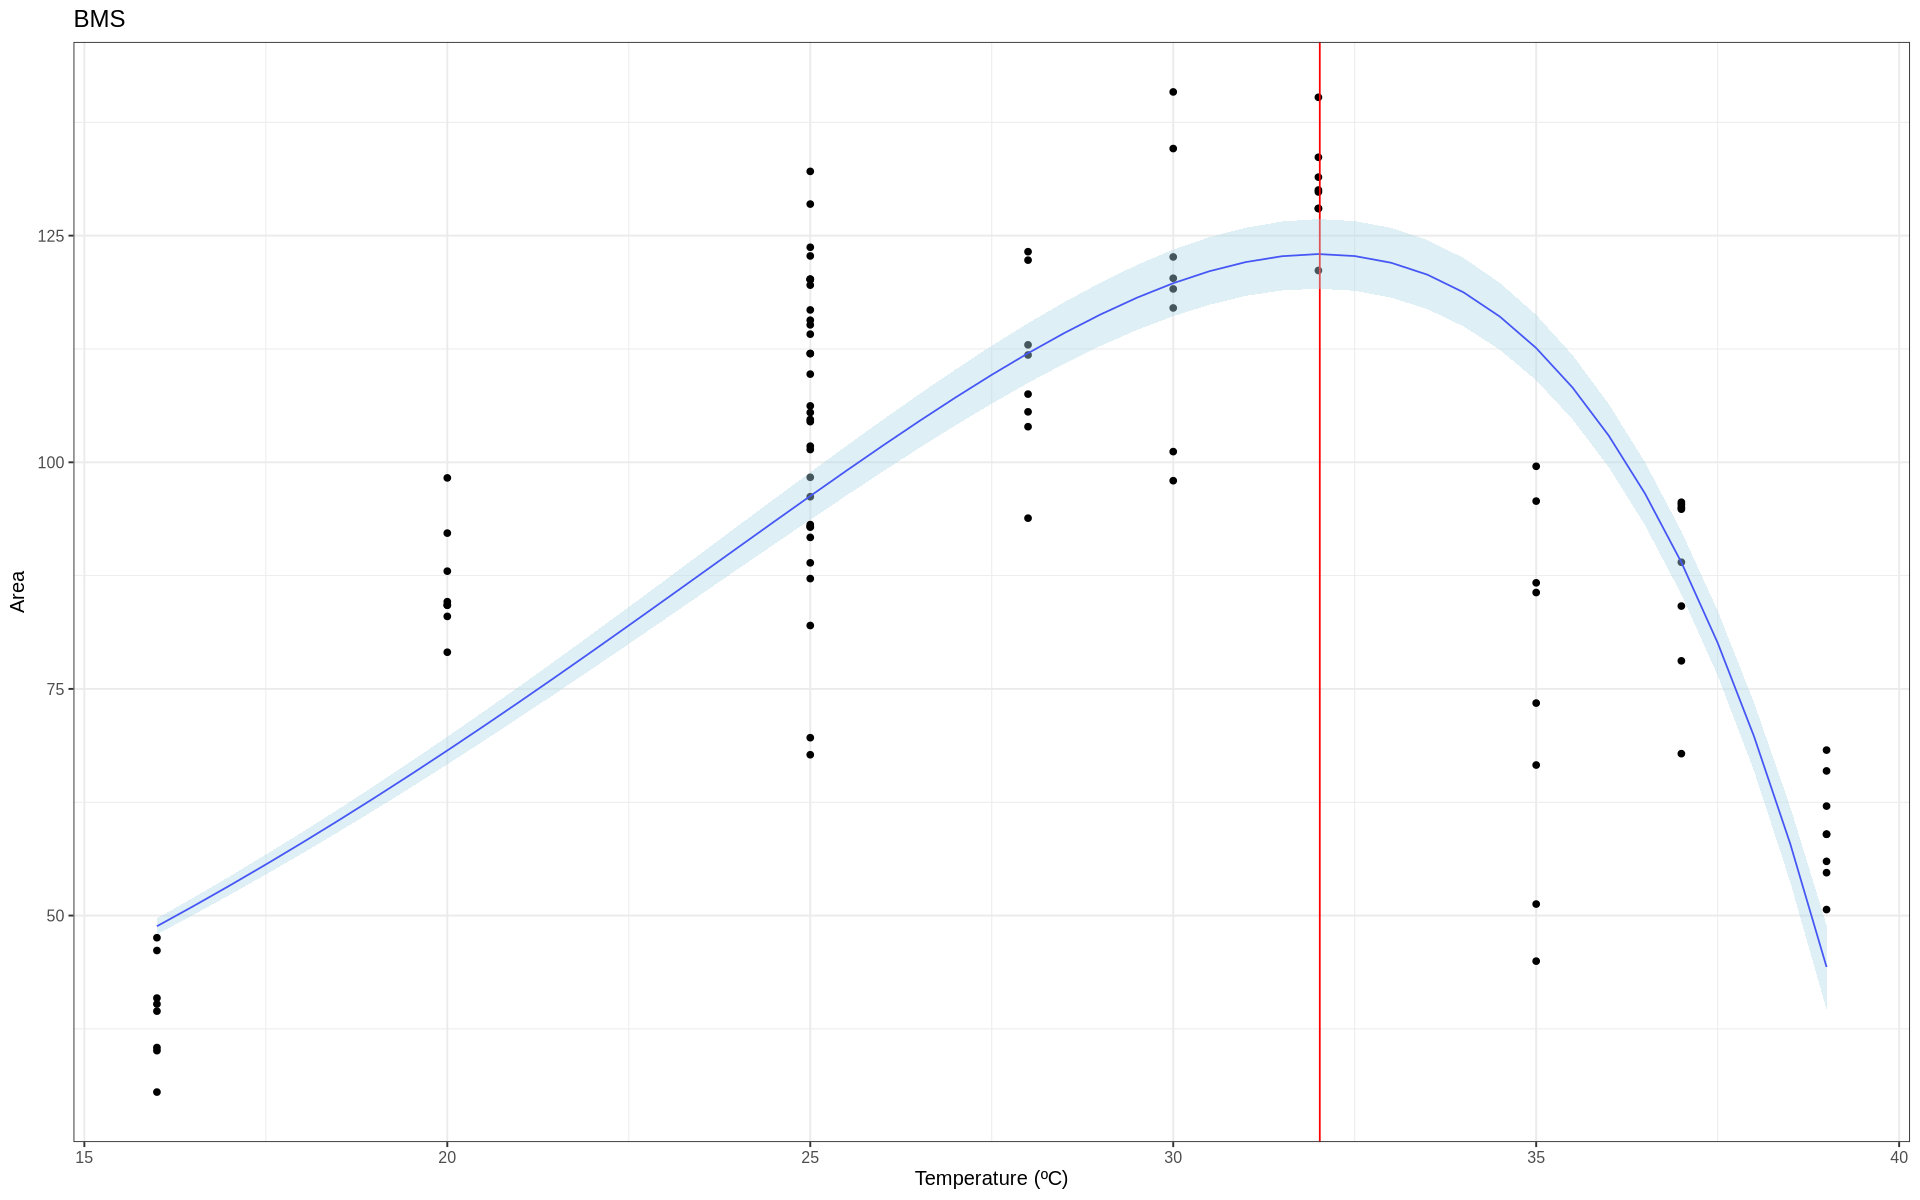

In [28]:
line_plots

In [29]:
# Get Topt Plot
CI_lims_cell_lines <- data.frame(t(data.frame(CI_lims_cell_lines)))
colnames(CI_lims_cell_lines) <- c("low", "high")
CI_lims_cell_lines$Cell_Line <- rownames(CI_lims_cell_lines)
CI_lims_cell_lines
max(CI_lims_cell_lines$high)
min(CI_lims_cell_lines$low)

,low,high,Cell_Line
,<dbl>,<dbl>,<chr>
CC1690,31.78298,32.187,CC1690
CC1691,31.77298,32.325,CC1691
CC1952,32.14800,32.667,CC1952
CC2342,30.94500,31.527,CC2342
CC2343,31.31500,31.731,CC2343
CC2344,31.47400,32.356,CC2344
CC2931,31.68200,32.386,CC2931
CC3059,31.63998,32.014,CC3059
CC4532,31.31400,31.529,CC4532


[1] 32.667

[1] 30.945

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


agg_record_592569688 
                   2

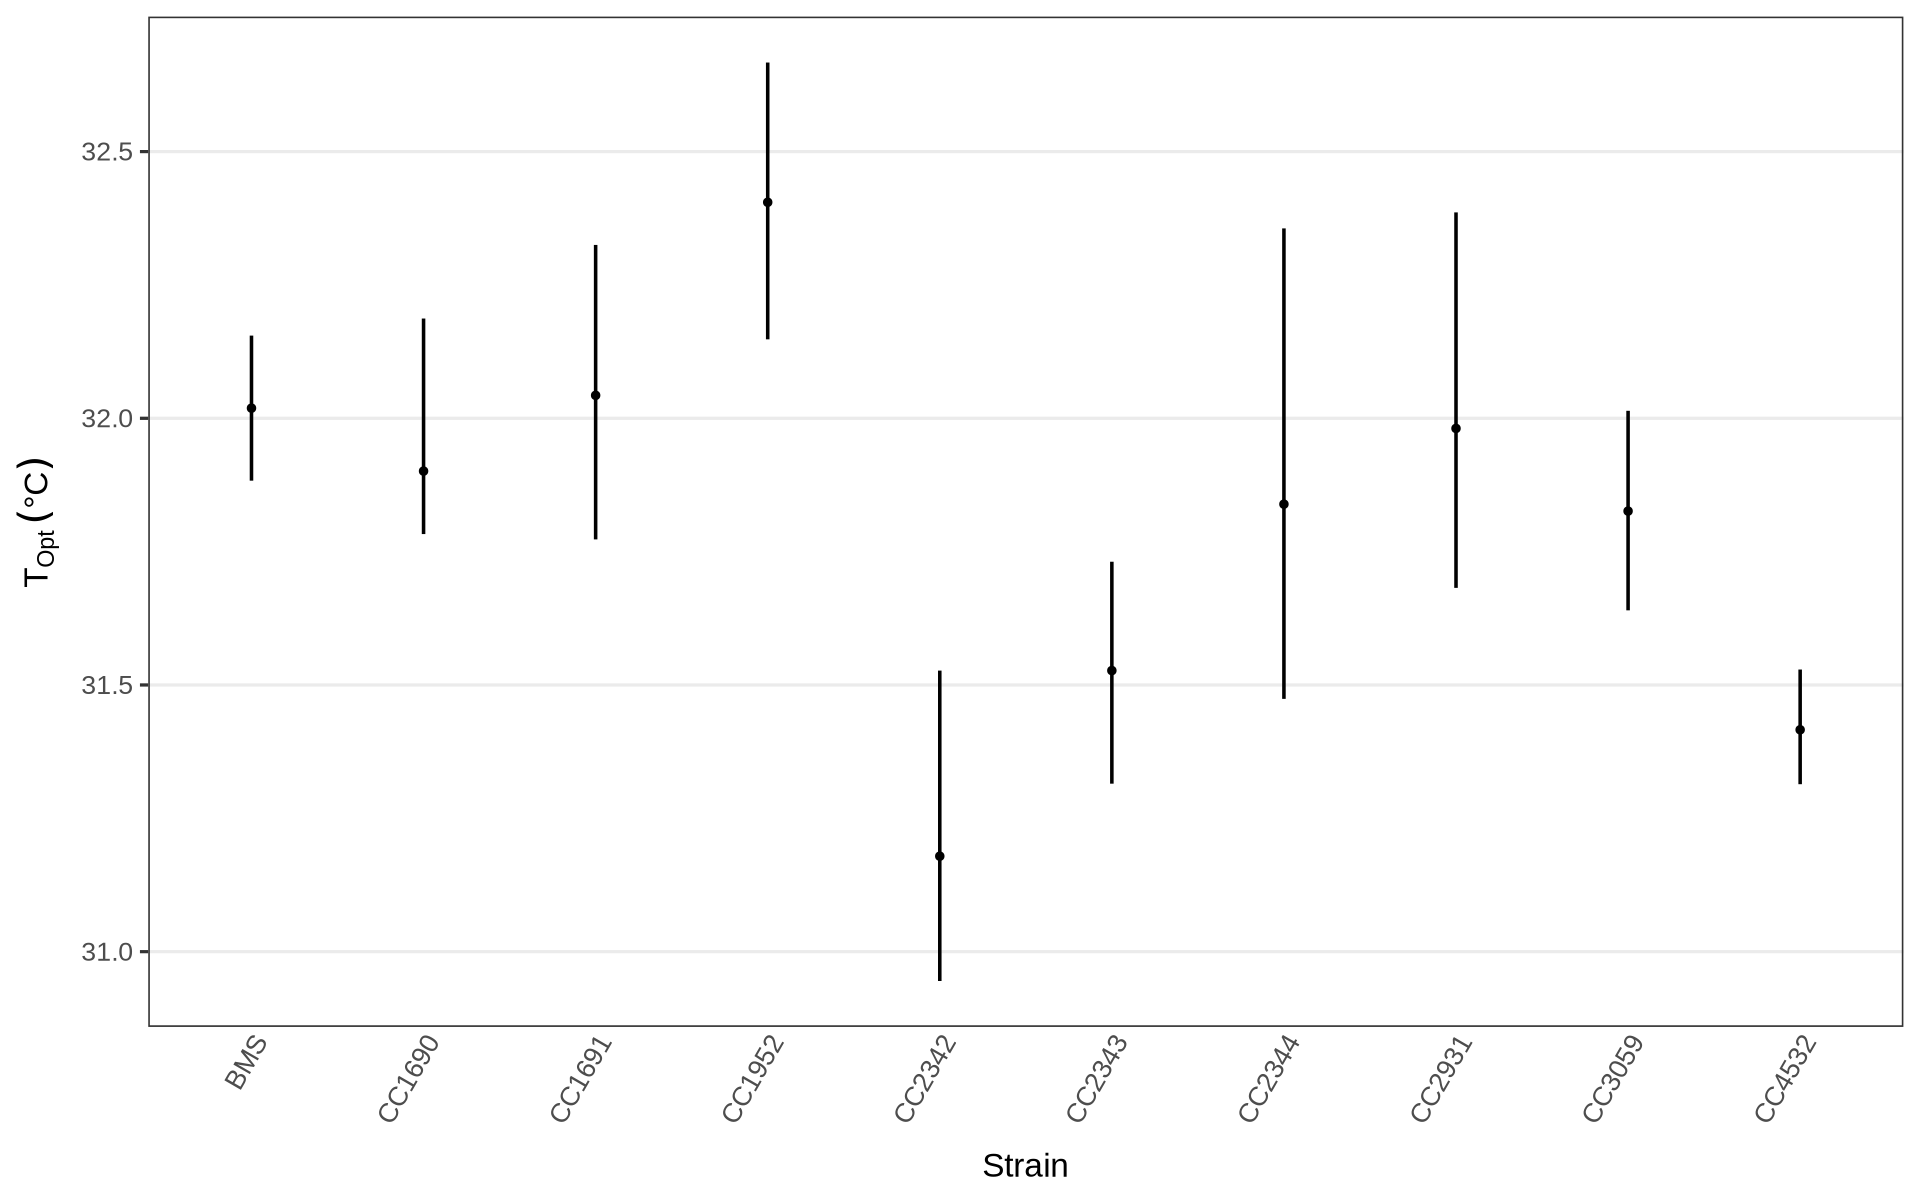

In [30]:
topt_plot <- ggplot(data = CI_lims_cell_lines, aes(x = Cell_Line))+
    geom_point(data = topts, aes(x = Cell_Line, y = topt), size = 2)+
    theme_bw(base_size = 20) +
    theme(panel.grid.minor = element_blank(), 
         panel.grid.major.x = element_blank(), 
        axis.ticks.x = element_blank(),
         axis.text.x = element_text(angle = 60, hjust = 1, vjust = 1.1))+
    labs(x = "Strain", y = expression("T"["Opt "]("°C")))+
    geom_linerange(aes(ymin = low, ymax = high), size = 1)

topt_plot

#Export Plot
pdf("topt_plot.pdf", height = 6, width = 8) 
topt_plot
dev.off()

In [31]:
# Edit model curve plots
# 16, 20, 28, 30, 32, 35, 37, and 39°C
edit_plots <- c()
for (line in cell_lines){
    if (line %in% c("CC1690", "CC1691", "CC1952", "CC2342")){ # If on the top row, get rid of the x axis
        plot <- line_plots[[line]] +
            theme_bw(25) +
            geom_vline(xintercept = 16, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 20, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 28, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 30, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 32, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 35, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 37, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 39, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 25, linetype = "dotted", size = 1, col = "grey80")+
            theme(plot.title = element_text(size=22, hjust = 0.5), 
                  panel.grid.minor = element_blank(), 
                  axis.text.x = element_blank(), 
                  axis.ticks.x = element_blank(),
                  axis.text.y = element_blank(), 
                  axis.ticks.y = element_blank(),
                  plot.margin = unit(c(0,r = 0.2,-0.2,-0.2), "cm")) +
            labs(y = "", x = "") +
            ylim(15, 150)
    } else if (line == "BMS") {
        plot <- line_plots[[line]] +
            geom_vline(xintercept = 16, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 20, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 28, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 30, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 32, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 35, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 37, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 39, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 25, linetype = "dotted", size = 1, col = "grey80")+
            theme_bw(25) +
            theme(plot.title = element_text(size=22, hjust = 0.5), 
                  panel.grid.minor = element_blank(), 
                  axis.text.x = element_blank(), 
                  axis.ticks.x = element_blank(),
                  plot.margin = unit(c(0,r = 0.2,-0.2,-0.2), "cm")) +
            labs(y = "", x = "") +
            ylim(15, 150)
    } else if (line == "CC2343") {
        plot <- line_plots[[line]] +
            theme_bw(25) +
            geom_vline(xintercept = 16, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 20, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 28, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 30, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 32, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 35, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 37, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 39, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 25, linetype = "dotted", size = 1, col = "grey80")+
            theme(plot.title = element_text(size=22, hjust = 0.5), 
                  panel.grid.minor = element_blank(),
                  axis.text.x = element_text(angle = 90, vjust = 0.5),
                  plot.margin = unit(c(t = 0, r = 0.2, b = -0.2,l = -0.2), "cm")) +
            labs(y = "", x = "") +
            ylim(15, 150)
    } else {
        plot <- line_plots[[line]] +
            theme_bw(25) +
            geom_vline(xintercept = 16, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 20, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 28, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 30, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 32, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 35, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 37, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 39, linetype = "dotted", size = 1, col = "grey80")+
            geom_vline(xintercept = 25, linetype = "dotted", size = 1, col = "grey80")+
            theme(plot.title = element_text(size=22, hjust = 0.5), 
                  axis.text.x = element_text(angle = 90, vjust = 0.5),
                  axis.text.y = element_blank(), 
                  axis.ticks.y = element_blank(),
                  panel.grid.minor = element_blank(), 
                  plot.margin = unit(c(0,r = 0.2,-0.2,-0.2), "cm")) +
            labs(y = "", x = "") +
            ylim(15, 150)
    }
    
        # labs(x = "Experimental Temperature (°C)", 
        #      y= expression(atop("Cell Density", atop("Based on AUC of growth curves taken at 680nm"))))
        # If want to add Topt CI
        # geom_rect(data = CI_lims_cell_lines %>% filter(Cell_Line == "BMS"), 
        #           aes(xmin=low, xmax=high, ymin=Inf, ymax=-Inf), fill = "grey100", alpha = 0.5, inherit.aes = F)
    # Edit the existing data
    q <- ggplot_build(plot)
    # Change the alpha of the points
    q$data[[1]]$alpha <- 0

    #Change the trendline width
    q$data[[2]]$linewidth <- 1
    
    # Change the Topt line
    q$data[[3]]$colour <- "black" 
    q$data[[3]]$linetype <- "dashed"
    
    # Change the CI
    q$data[[4]]$fill <- "grey50"

    
    edit_plots[[line]] <- ggplot_gtable(q)
}

Warning message:
“Removed 14 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”


In [32]:
library(cowplot)
library(gridExtra)
library(grid)

options(repr.plot.width=20, repr.plot.height=10) #make all the plots large
cell_lines
p <- plot_grid(edit_plots[["BMS"]], 
          edit_plots[["CC1690"]], 
          edit_plots[["CC1691"]], 
          edit_plots[["CC1952"]],
          edit_plots[["CC2342"]],
          edit_plots[["CC2343"]],
          edit_plots[["CC2344"]],
          edit_plots[["CC2931"]],
          edit_plots[["CC3059"]],
          edit_plots[["CC4532"]], nrow = 2,rel_widths = c(1.1, 1,1,1,1,1.1,1,1,1,1,1))

y.grob <- textGrob("Cumulative Cell Density", gp=gpar(fontsize=25), rot=90)
# y.grob <- textGrob(expression(atop("Cumulative Cell Density", atop("Based on AUC of growth curves taken at OD"[680]))), gp=gpar(fontsize=25), rot=90)
# y.grob <- textGrob(expression('OD'[680]), gp=gpar(fontsize=20), rot=90)
x.grob <- textGrob("Experimental Temperature (°C)", gp=gpar(fontsize=25))


#Export Plot
# pdf("Screen_Bootstrapped_Curves.pdf", height = 8, width = 15) 
# grid.arrange(arrangeGrob(p, left = y.grob, bottom = x.grob))
# dev.off()


Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




[1] "CC1690" "CC1691" "CC1952" "CC2342" "CC2343" "CC2344" "CC2931" "CC3059"
 [9] "CC4532" "BMS"

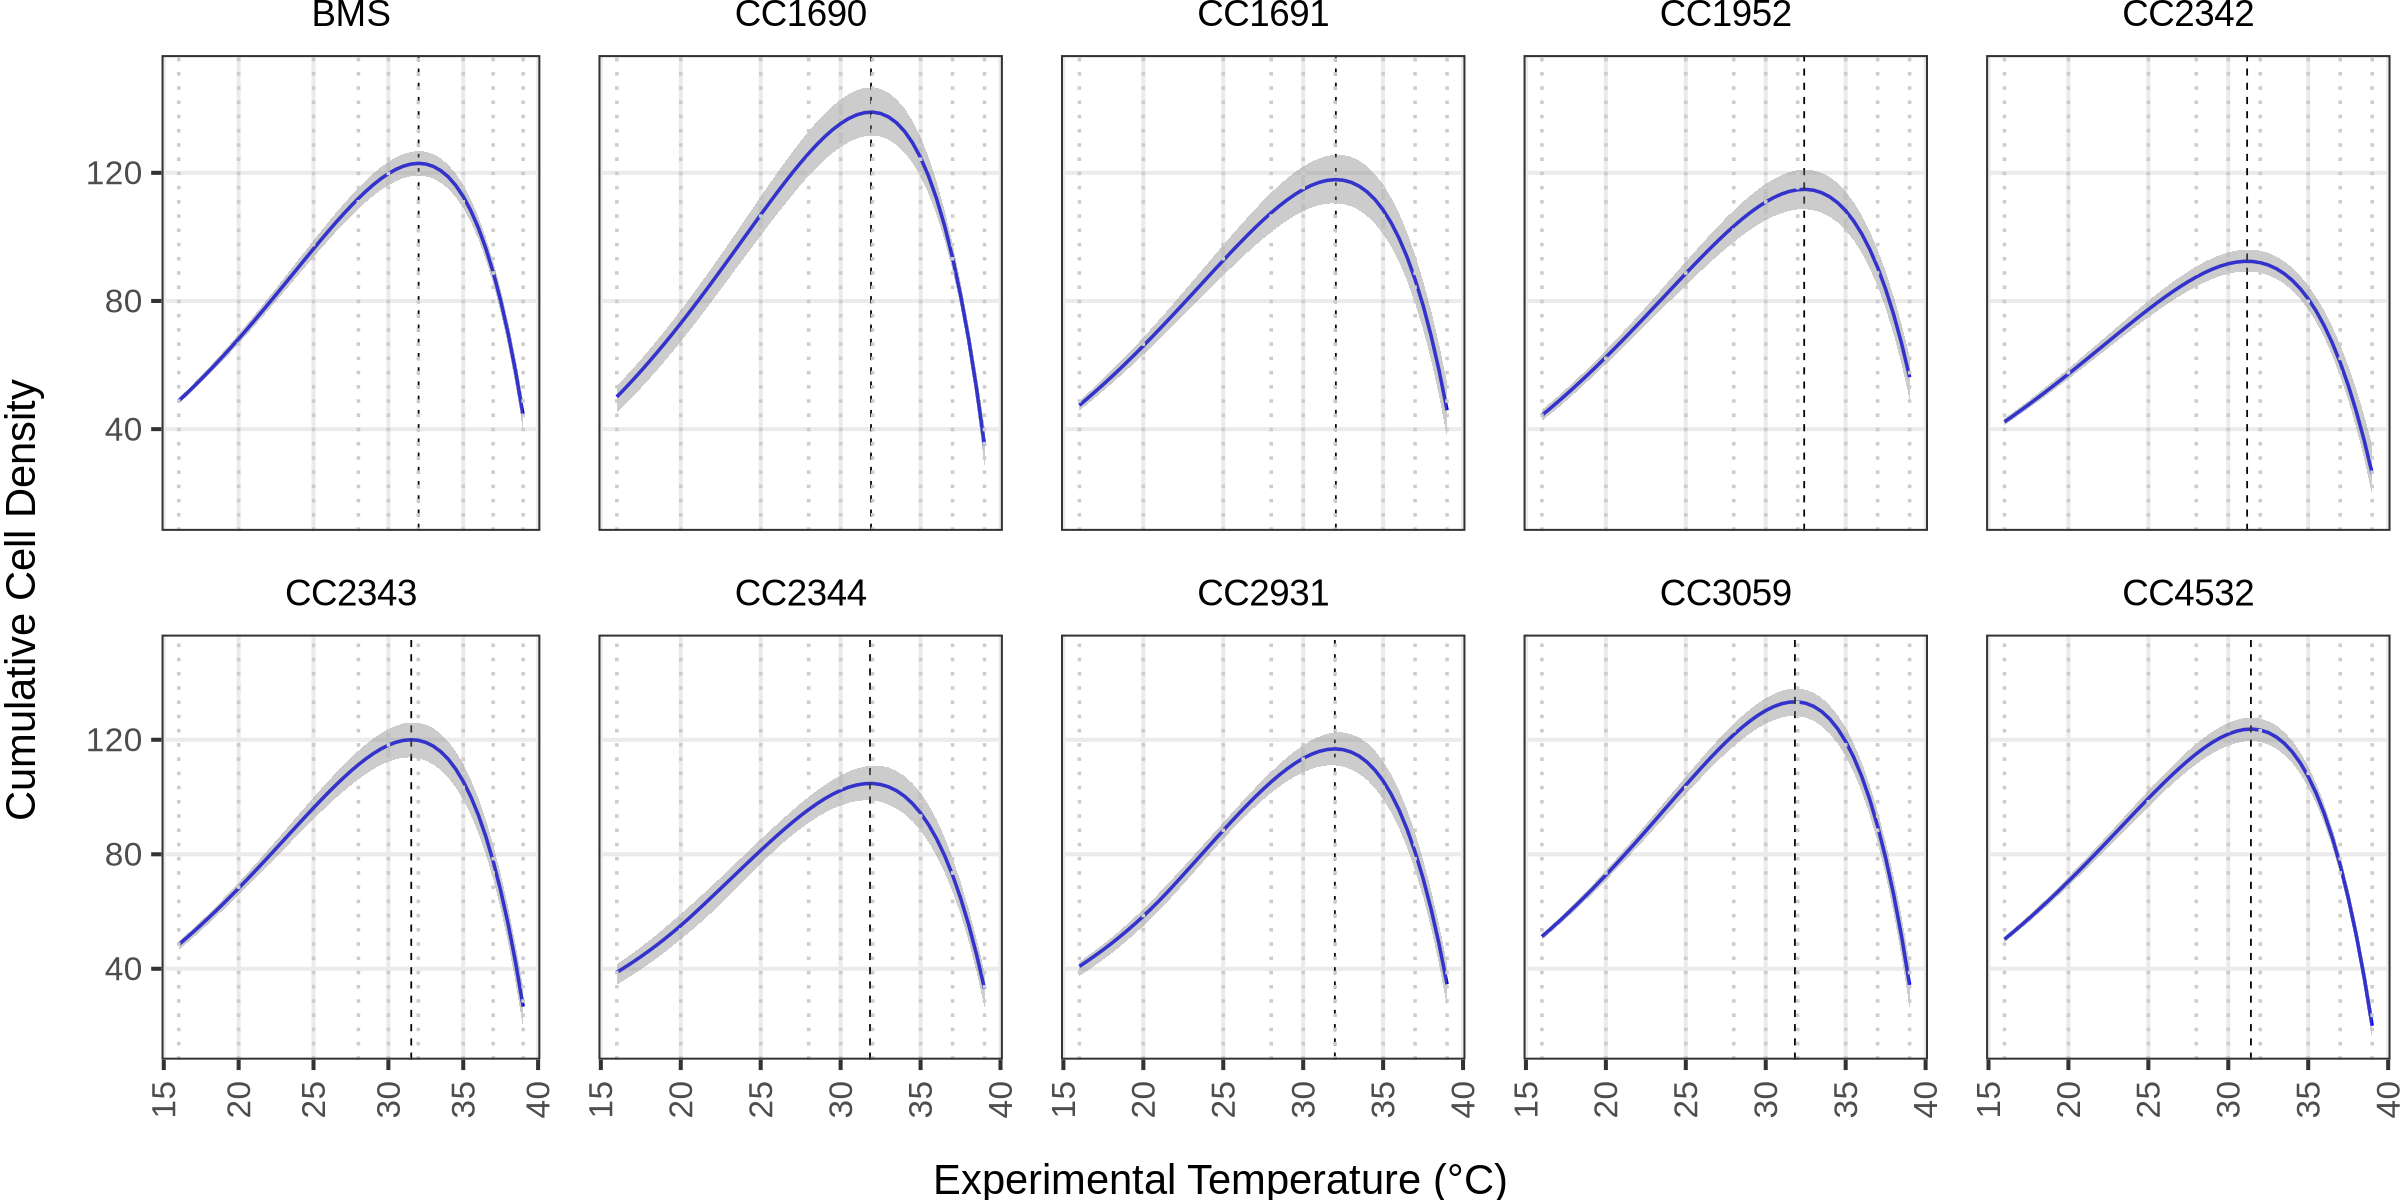

In [33]:
grid.arrange(arrangeGrob(p, left = y.grob, bottom = x.grob))